# Y (目標變數) | fraud_reported 預測(欺詐辨識) >> 影響核保、理賠(避免財務損失)

## 資料探勘 

In [1]:
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\專案_保險資料分析'

In [2]:
os.listdir()

['.ipynb_checkpoints', 'insurance_claims_data.csv', '專案2.ipynb']

In [3]:
import pandas as pd
df = pd.read_csv("insurance_claims_data.csv")

In [4]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [5]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [7]:
df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

### Column Meaning

* months_as_customer 購買月份累計       
* age 年齡    
* policy_number 保單編號                    
* policy_bind_date 保單生效日                 
* policy_state 保單簽署所在的州 (IL:Illinois, IN:Indiana, OH:Ohio)                    
* policy_csl 保險公司賠償的金額上限，單位千 (每人/每場事故)                        
* policy_deductable 自負額                 
* policy_annual_premium 每年保費            
* umbrella_limit 超額責任保險額度，即賠償超過csl時，且有買umbrella_limit可以多承擔的賠償                  
* insured_zip 被保人郵遞區號                      
* insured_sex 性別    
* insured_education_level 教育程度          
* insured_occupation 職業    
* insured_hobbies 興趣                  
* insured_relationship 婚配             
* capital-gains 資本利得                    
* capital-loss 資本虧損                      
* incident_date 意外日期 (日期差不多不採用)                   
* incident_type 意外類型                    
* collision_type 事故碰撞類型 (Rear:追撞, Side:側撞, Front:正面)                   
* incident_severity 嚴重程度                 
* authorities_contacted 聯絡的機關
* incident_state 意外所在的州                   
* incident_city 意外所在的城市                     
* incident_location 意外所在位置                
* incident_hour_of_the_day 車禍發生時間         
* number_of_vehicles_involved 意外幾輛車受損      
* property_damage 財產損失                  
* bodily_injuries 身體受傷                  
* witnesses 目擊證人                         
* police_report_available 警方介入          
* total_claim_amount 事故總理賠金額 = injury_claim + property_claim + vehicle_claim            
* injury_claim 受傷理賠                      
* property_claim 財產理賠                   
* vehicle_claim 汽車理賠                     
* auto_make 汽車廠牌                         
* auto_model 汽車型號                       
* auto_year 汽車製造年                        
* fraud_reported 詐欺案件                    

## 特徵工程

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

### months_as_customer 

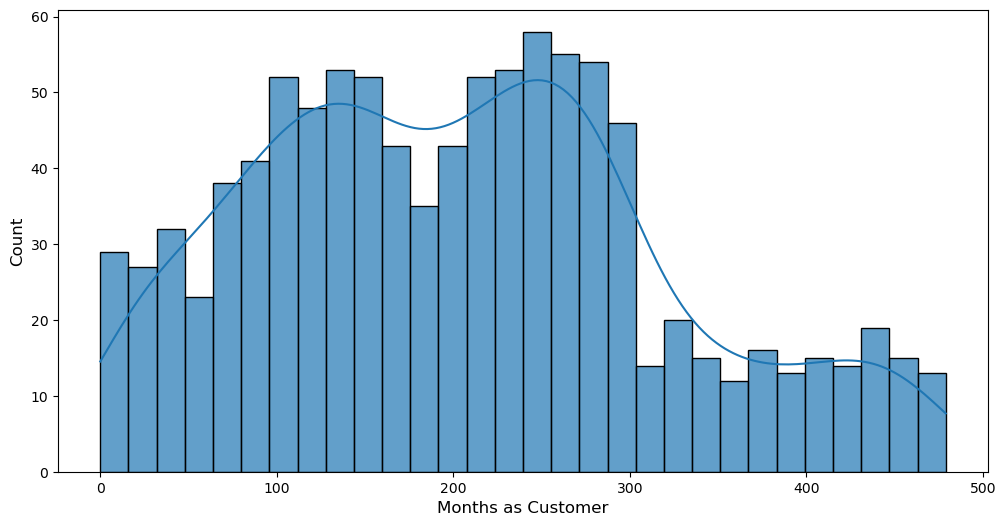

In [9]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['months_as_customer'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Months as Customer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

<Axes: xlabel='months_as_customer'>

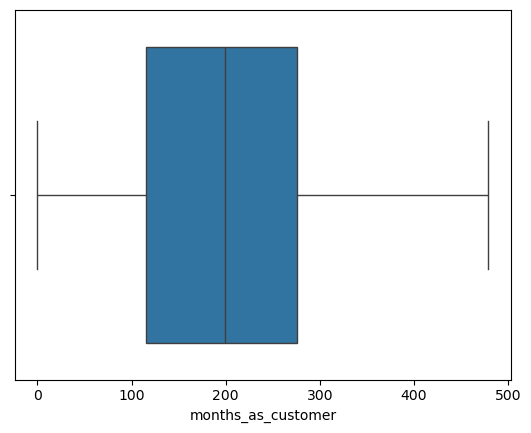

In [10]:
sns.boxplot(x=df['months_as_customer'])

### age

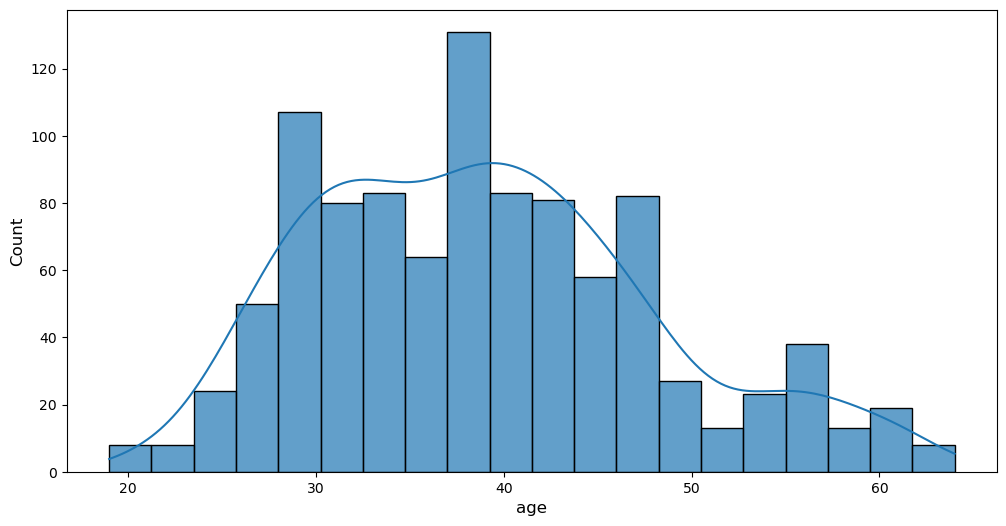

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

<Axes: xlabel='age'>

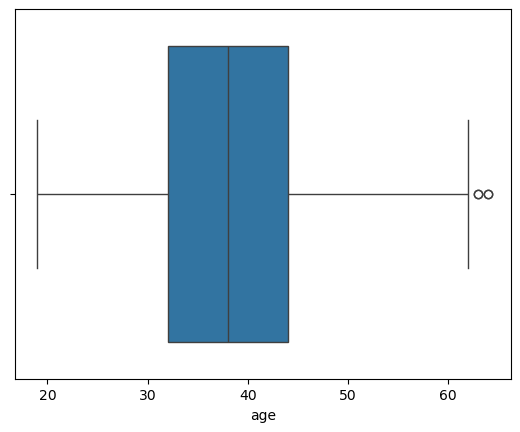

In [12]:
sns.boxplot(x=df['age'])

### policy_number (X)

### policy_bind_date => policy_bind_year(X) and policy_bind_month and policy_bind_weekday(X) and policy_bind_daytype

In [13]:
df["policy_bind_date"].head()

0    2014-10-17
1    2006-06-27
2    2000-09-06
3    1990-05-25
4    2014-06-06
Name: policy_bind_date, dtype: object

In [14]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])

In [15]:
df["policy_bind_year"] = df["policy_bind_date"].dt.year
df["policy_bind_month"] = df["policy_bind_date"].dt.month
df["policy_bind_weekday"] = df["policy_bind_date"].dt.weekday

In [16]:
policy_bind_date_cols = ["policy_bind_year", "policy_bind_month", "policy_bind_weekday"]
for i in policy_bind_date_cols:
    print(df[i].head())

0    2014
1    2006
2    2000
3    1990
4    2014
Name: policy_bind_year, dtype: int32
0    10
1     6
2     9
3     5
4     6
Name: policy_bind_month, dtype: int32
0    4
1    1
2    2
3    4
4    4
Name: policy_bind_weekday, dtype: int32


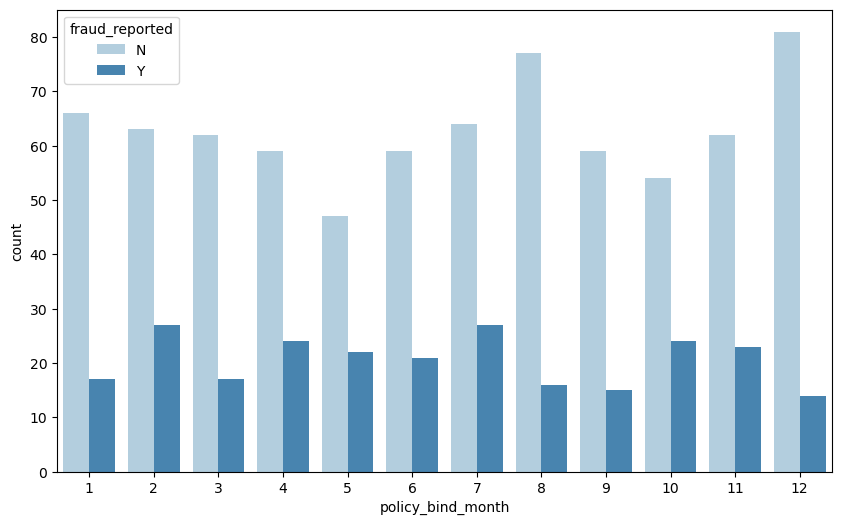

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='policy_bind_month',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

In [18]:
df['policy_bind_daytype'] = df['policy_bind_weekday'].apply(
    lambda x: 'weekday' if x < 5 else 'weekend'
)

In [19]:
pd.get_dummies(df['policy_bind_daytype'], drop_first=True)

,weekend
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,True
997,False
998,False


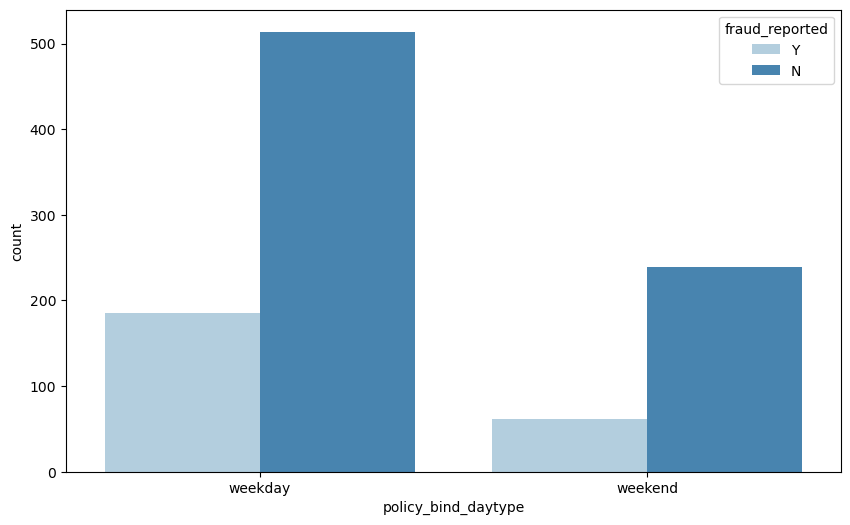

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='policy_bind_daytype',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### policy_state 

In [21]:
df.policy_state.value_counts()

policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

In [22]:
pd.get_dummies(df, columns=['policy_state'])

,months_as_customer,age,policy_number,policy_bind_date,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,auto_year,fraud_reported,_c39,policy_bind_year,policy_bind_month,policy_bind_weekday,policy_bind_daytype,policy_state_IL,policy_state_IN,policy_state_OH
0,328,48,521585,2014-10-17,250/500,1000,1406.91,0,466132,MALE,...,2004,Y,NaN,2014,10,4,weekday,False,False,True
1,228,42,342868,2006-06-27,250/500,2000,1197.22,5000000,468176,MALE,...,2007,Y,NaN,2006,6,1,weekday,False,True,False
2,134,29,687698,2000-09-06,100/300,2000,1413.14,5000000,430632,FEMALE,...,2007,N,NaN,2000,9,2,weekday,False,False,True
3,256,41,227811,1990-05-25,250/500,2000,1415.74,6000000,608117,FEMALE,...,2014,Y,NaN,1990,5,4,weekday,True,False,False
4,228,44,367455,2014-06-06,500/1000,1000,1583.91,6000000,610706,MALE,...,2009,N,NaN,2014,6,4,weekday,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,500/1000,1000,1310.80,0,431289,FEMALE,...,2006,N,NaN,1991,7,1,weekday,False,False,True
996,285,41,186934,2014-01-05,100/300,1000,1436.79,0,608177,FEMALE,...,2015,N,NaN,2014,1,6,weekend,True,False,False
997,130,34,918516,2003-02-17,250/500,500,1383.49,3000000,442797,FEMALE,...,1996,N,NaN,2003,2,0,weekday,False,False,True
998,458,62,533940,2011-11-18,500/1000,2000,1356.92,5000000,441714,MALE,...,1998,N,NaN,2011,11,4,weekday,True,False,False


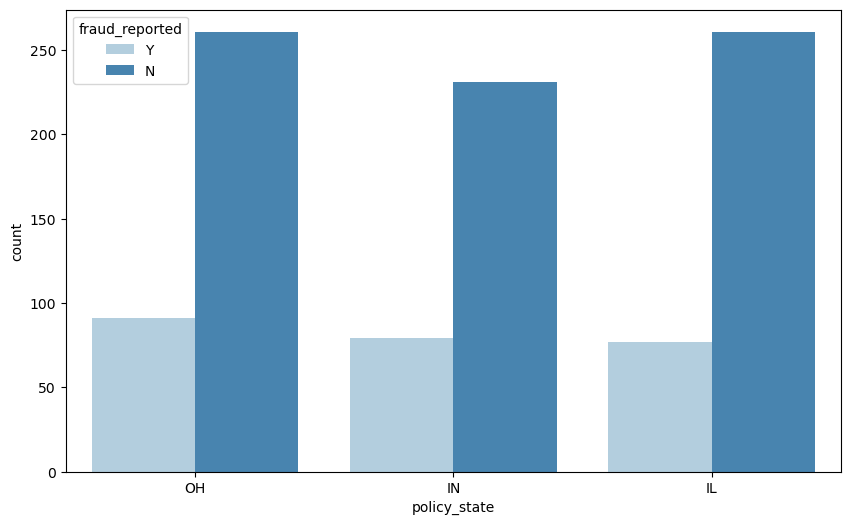

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='policy_state',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### policy_csl => csl_person and csl_accident

In [24]:
df[["csl_person","csl_accident"]] = df["policy_csl"].str.split("/", expand=True)

In [25]:
df["csl_person"] = df["csl_person"].astype(int)
df["csl_accident"] = df["csl_accident"].astype(int)

In [26]:
df["csl_person"].head()

0    250
1    250
2    100
3    250
4    500
Name: csl_person, dtype: int64

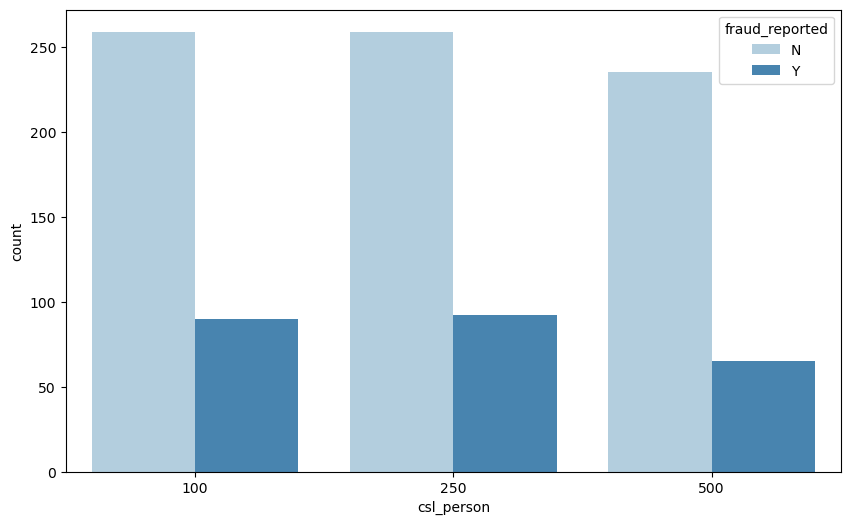

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='csl_person',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

In [28]:
df["csl_accident"].head()

0     500
1     500
2     300
3     500
4    1000
Name: csl_accident, dtype: int64

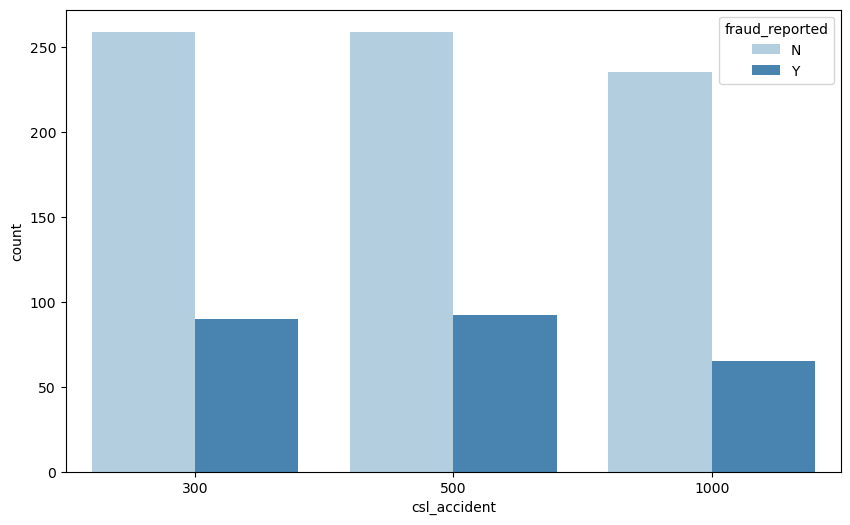

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='csl_accident',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### policy_deductable

In [30]:
df.policy_deductable.value_counts()

policy_deductable
1000    351
500     342
2000    307
Name: count, dtype: int64

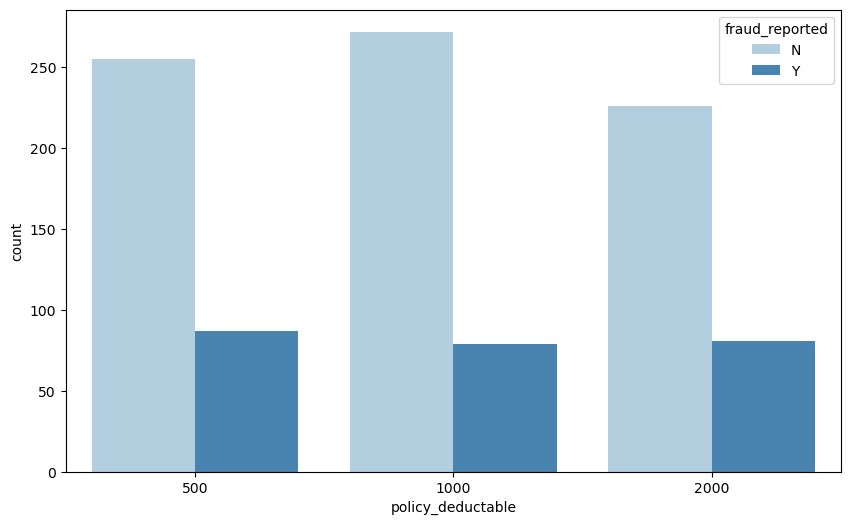

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='policy_deductable',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### policy_annual_premium 有極端值但幅度不大不做處理

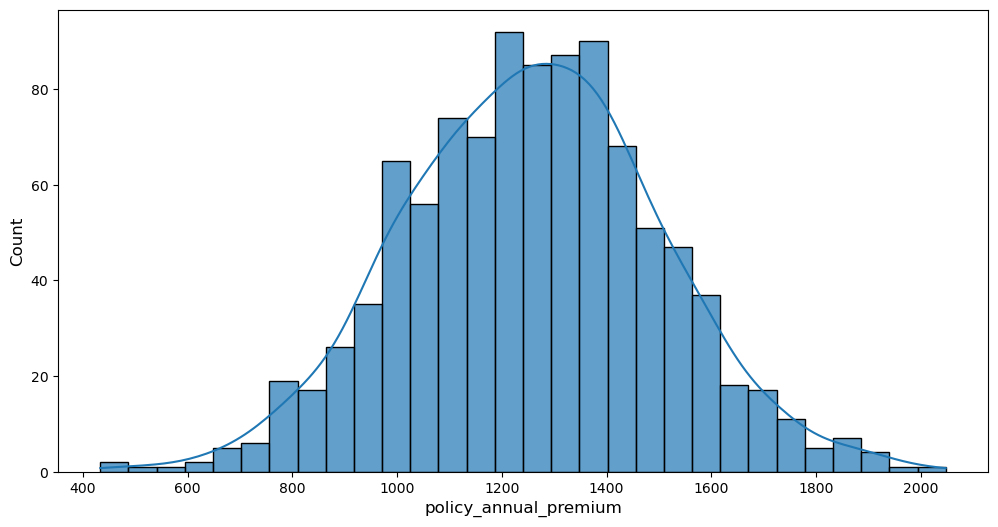

In [32]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['policy_annual_premium'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('policy_annual_premium', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [33]:
df['policy_annual_premium'].max(), df['policy_annual_premium'].min()

(2047.59, 433.33)

<Axes: xlabel='policy_annual_premium'>

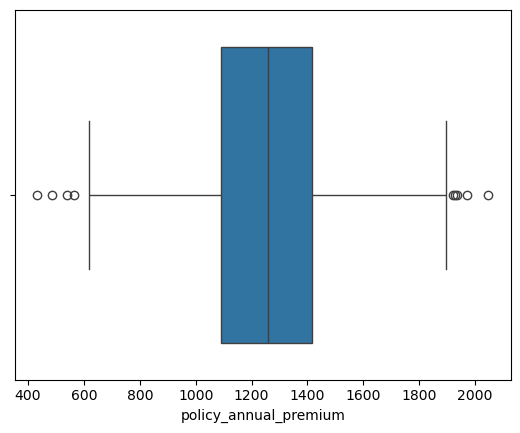

In [34]:
import seaborn as sns
sns.boxplot(x=df['policy_annual_premium'])

### umbrella_limit => umbrella_limit_yes and umbrella_limit_no

In [35]:
df.umbrella_limit.value_counts()

umbrella_limit
 0           798
 6000000      57
 5000000      46
 4000000      39
 7000000      29
 3000000      12
 8000000       8
 9000000       5
 2000000       3
 10000000      2
-1000000       1
Name: count, dtype: int64

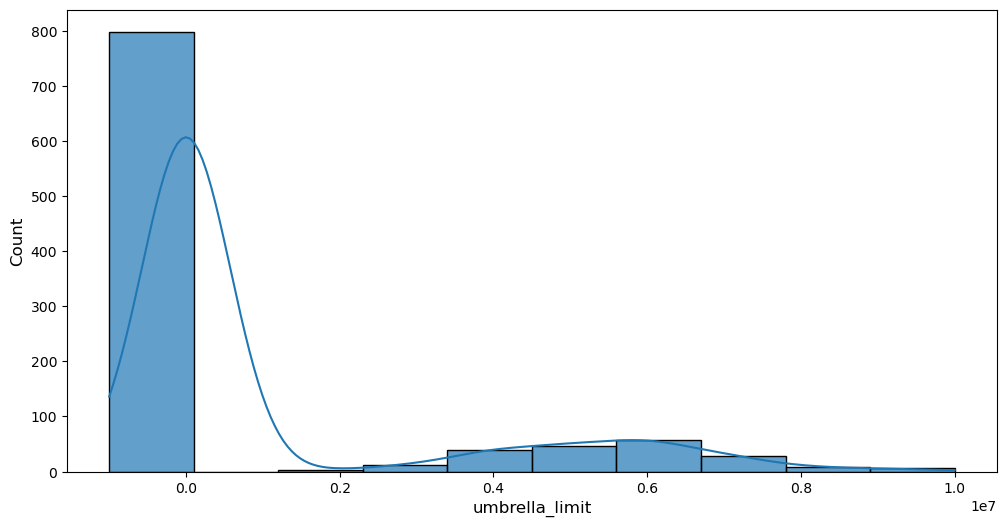

In [36]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['umbrella_limit'],
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('umbrella_limit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [37]:
df['umbrella_limit_yes'] = df[df['umbrella_limit'] > 0]['umbrella_limit']
df['umbrella_limit_no'] = df[df['umbrella_limit'] == 0]['umbrella_limit']

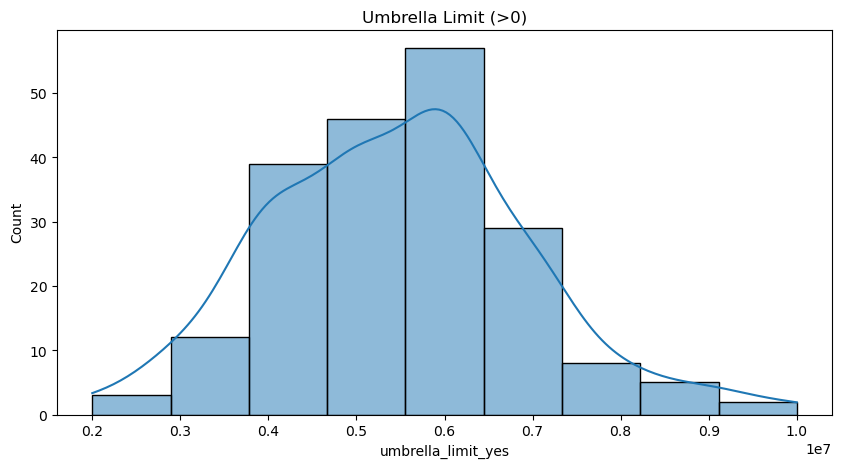

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['umbrella_limit_yes'],
    bins=9,
    kde=True
)

plt.title("Umbrella Limit (>0)")
plt.show()

In [39]:
df.umbrella_limit_no.value_counts()

umbrella_limit_no
0.0    798
Name: count, dtype: int64

### insured_zip(X)

### insured_sex

In [40]:
df.insured_sex.value_counts()

insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

In [41]:
pd.get_dummies(df.insured_sex)

,FEMALE,MALE
0,False,True
1,False,True
2,True,False
3,True,False
4,False,True
...,...,...
995,True,False
996,True,False
997,True,False
998,False,True


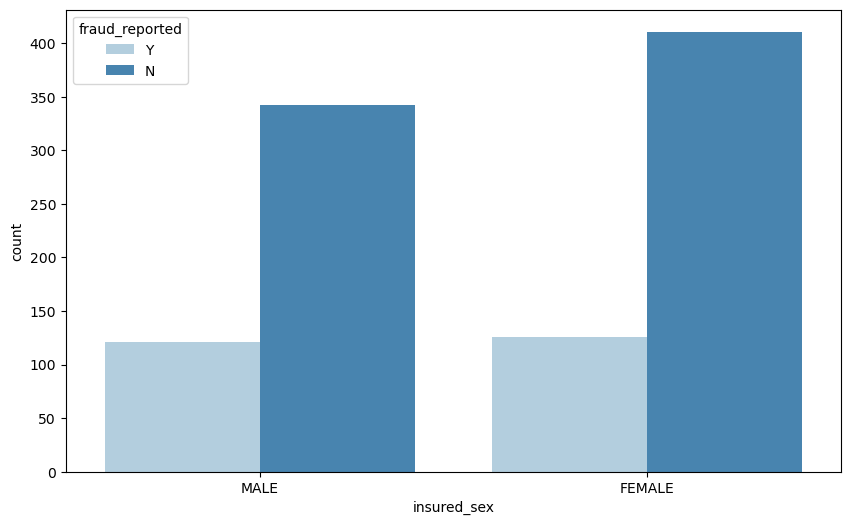

In [42]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='insured_sex',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### insured_education_level

In [43]:
df.insured_education_level.value_counts()

insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64

In [44]:
pd.get_dummies(df.insured_education_level)

,Associate,College,High School,JD,MD,Masters,PhD
0,False,False,False,False,True,False,False
1,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True
4,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,False,True,False
996,False,False,False,False,False,False,True
997,False,False,False,False,False,True,False
998,True,False,False,False,False,False,False


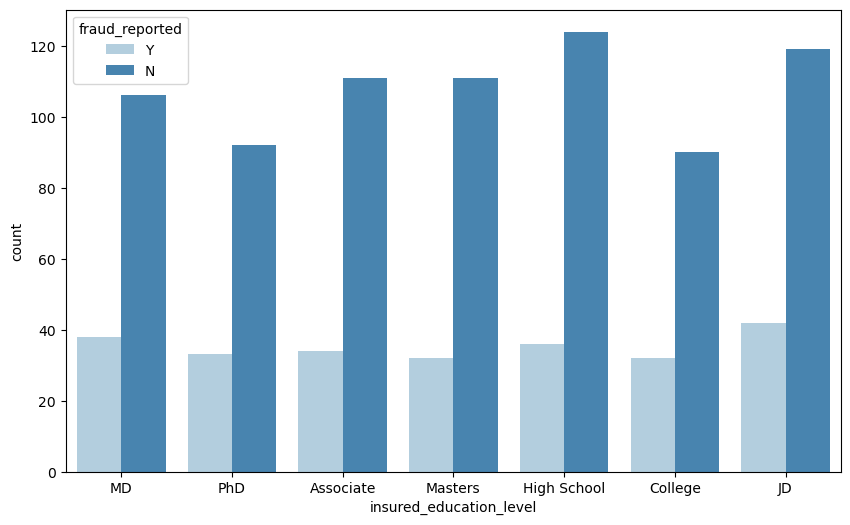

In [45]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='insured_education_level',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### insured_occupation

In [46]:
df['insured_occupation'].unique()

array(['craft-repair', 'machine-op-inspct', 'sales', 'armed-forces',
       'tech-support', 'prof-specialty', 'other-service',
       'priv-house-serv', 'exec-managerial', 'protective-serv',
       'transport-moving', 'handlers-cleaners', 'adm-clerical',
       'farming-fishing'], dtype=object)

In [47]:
df.insured_occupation.value_counts()

insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
craft-repair         74
transport-moving     72
other-service        71
priv-house-serv      71
armed-forces         69
adm-clerical         65
protective-serv      63
handlers-cleaners    54
farming-fishing      53
Name: count, dtype: int64

In [48]:
pd.get_dummies(df.insured_occupation)

,adm-clerical,armed-forces,craft-repair,exec-managerial,farming-fishing,handlers-cleaners,machine-op-inspct,other-service,priv-house-serv,prof-specialty,protective-serv,sales,tech-support,transport-moving
0,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,True,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,True,False,False,False,False
997,False,True,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,True,False,False,False,False,False,False,False,False


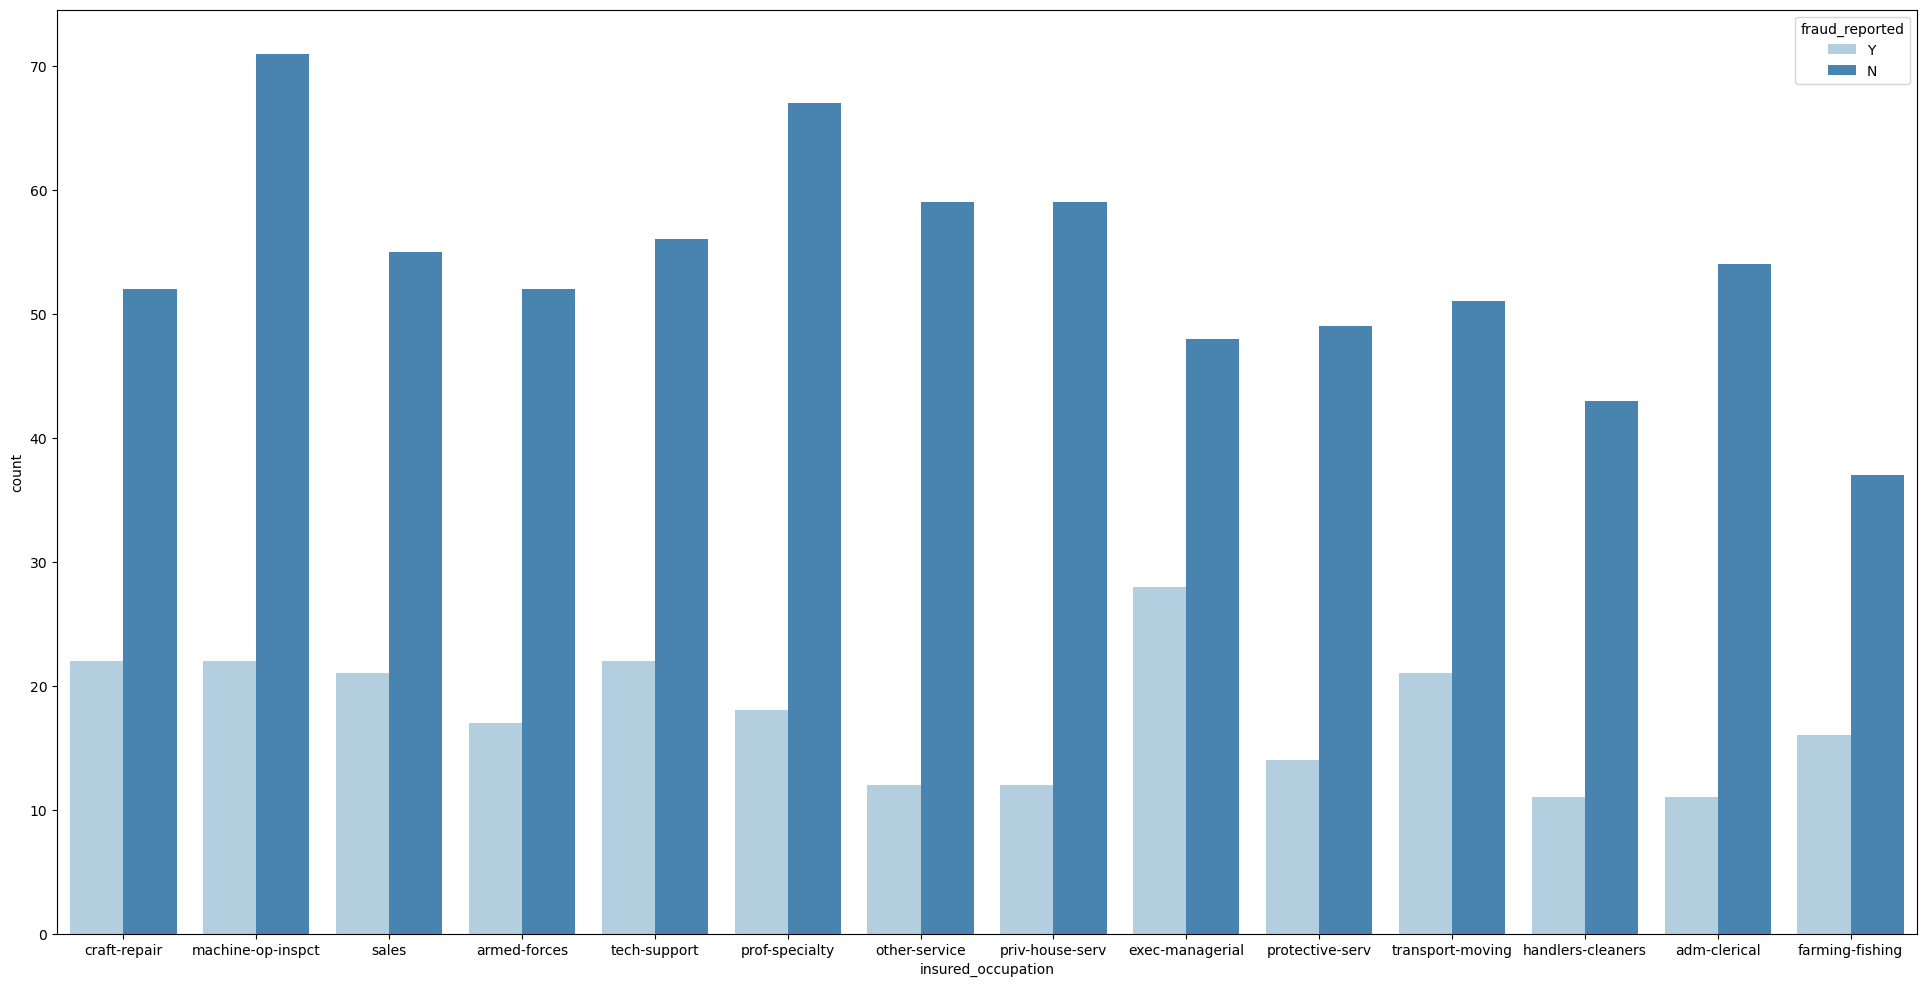

In [49]:
plt.figure(figsize=(24,12))

sns.countplot(
    x='insured_occupation',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### insured_hobbies

In [50]:
df['insured_hobbies'].unique()

array(['sleeping', 'reading', 'board-games', 'bungie-jumping',
       'base-jumping', 'golf', 'camping', 'dancing', 'skydiving',
       'movies', 'hiking', 'yachting', 'paintball', 'chess', 'kayaking',
       'polo', 'basketball', 'video-games', 'cross-fit', 'exercise'],
      dtype=object)

In [51]:
df.insured_hobbies.value_counts()

insured_hobbies
reading           64
exercise          57
paintball         57
bungie-jumping    56
movies            55
golf              55
camping           55
kayaking          54
yachting          53
hiking            52
video-games       50
skydiving         49
base-jumping      49
board-games       48
polo              47
chess             46
dancing           43
sleeping          41
cross-fit         35
basketball        34
Name: count, dtype: int64

In [52]:
pd.get_dummies(df.insured_hobbies)

,base-jumping,basketball,board-games,bungie-jumping,camping,chess,cross-fit,dancing,exercise,golf,hiking,kayaking,movies,paintball,polo,reading,skydiving,sleeping,video-games,yachting
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
997,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


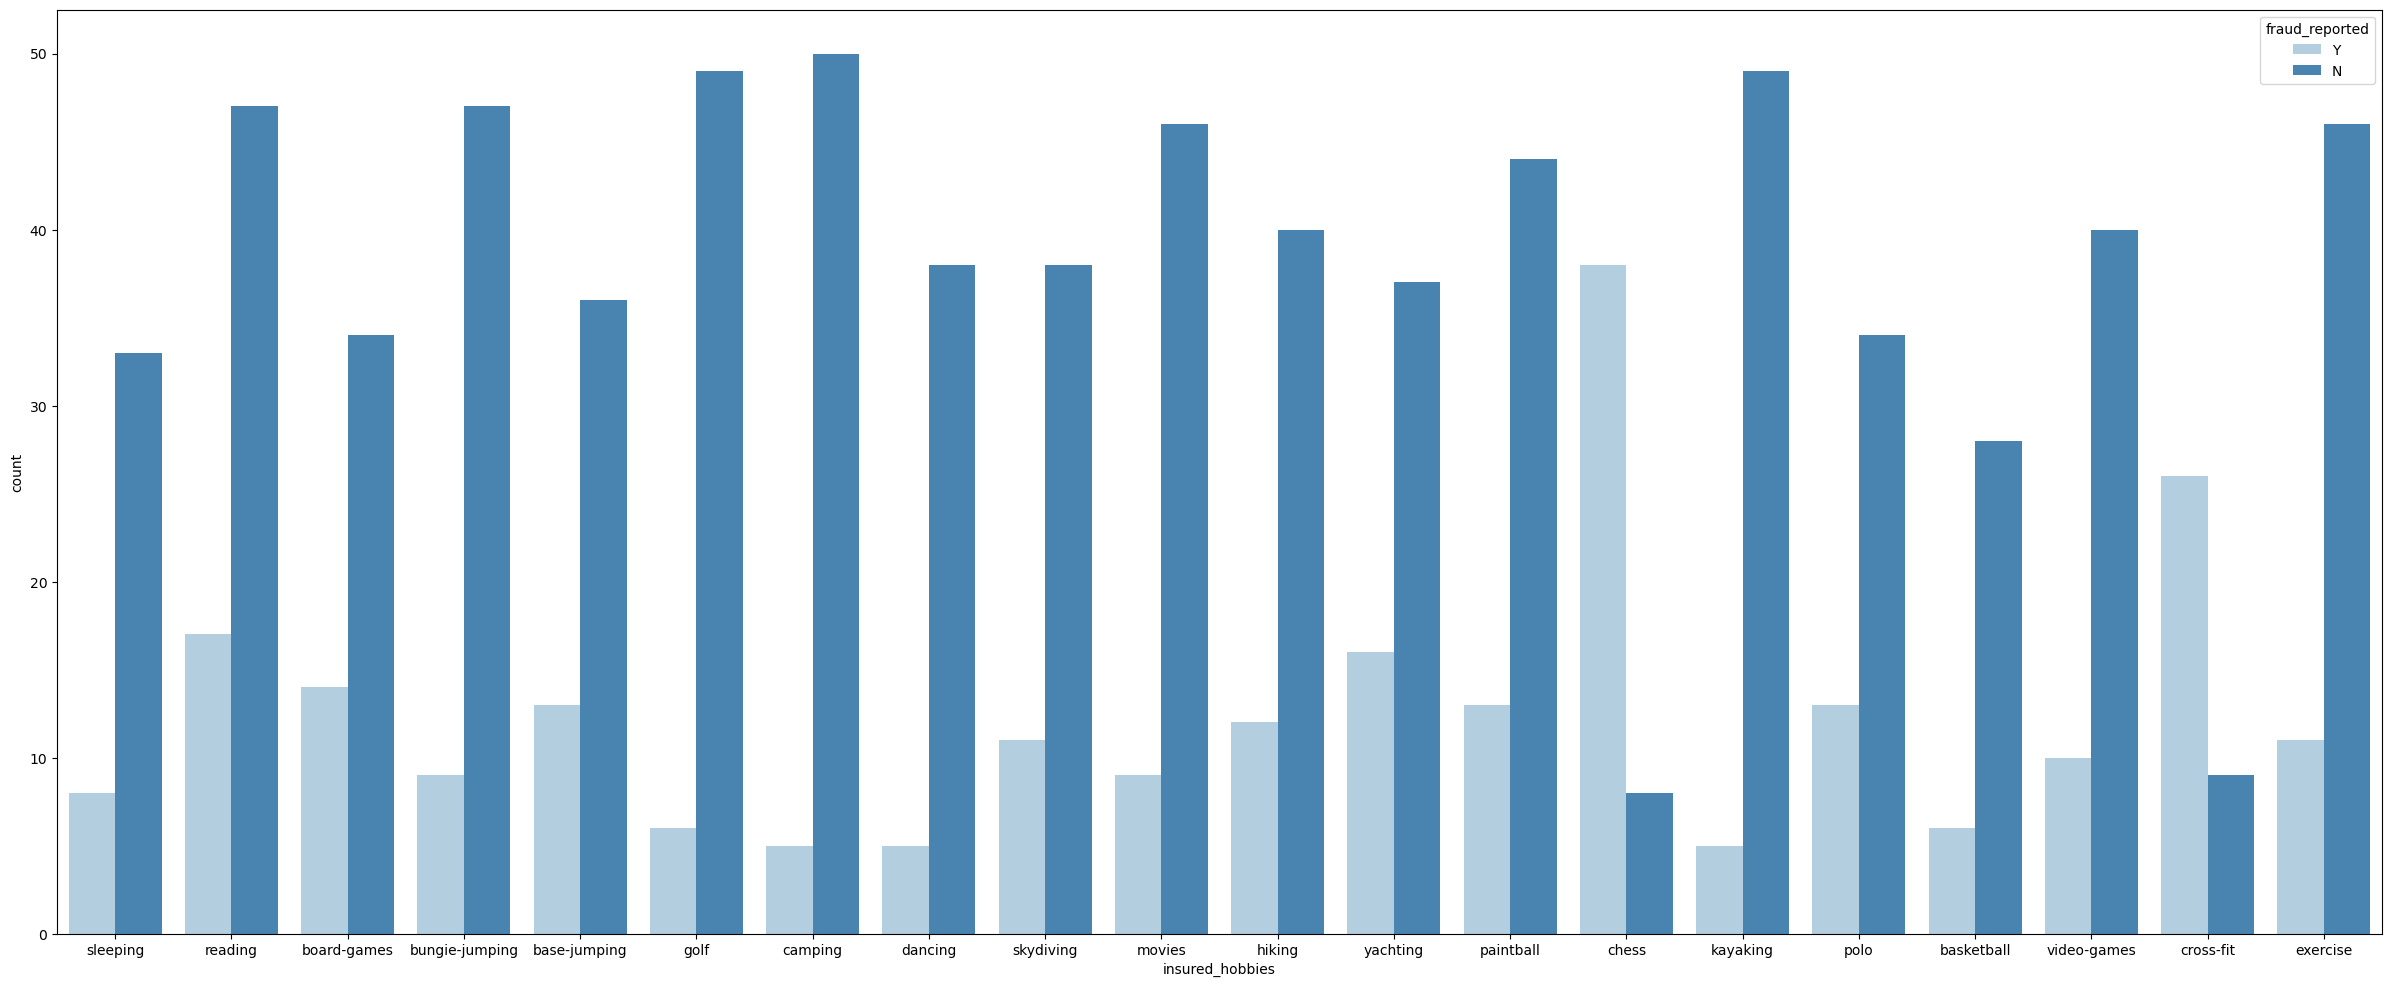

In [53]:
plt.figure(figsize=(30,12))

sns.countplot(
    x='insured_hobbies',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### insured_relationship

In [54]:
df.insured_relationship.value_counts()

insured_relationship
own-child         183
other-relative    177
not-in-family     174
husband           170
wife              155
unmarried         141
Name: count, dtype: int64

In [55]:
pd.get_dummies(df.insured_relationship)

,husband,not-in-family,other-relative,own-child,unmarried,wife
0,True,False,False,False,False,False
1,False,False,True,False,False,False
2,False,False,False,True,False,False
3,False,False,False,False,True,False
4,False,False,False,False,True,False
...,...,...,...,...,...,...
995,False,False,False,False,True,False
996,False,False,False,False,False,True
997,False,False,True,False,False,False
998,False,False,False,False,False,True


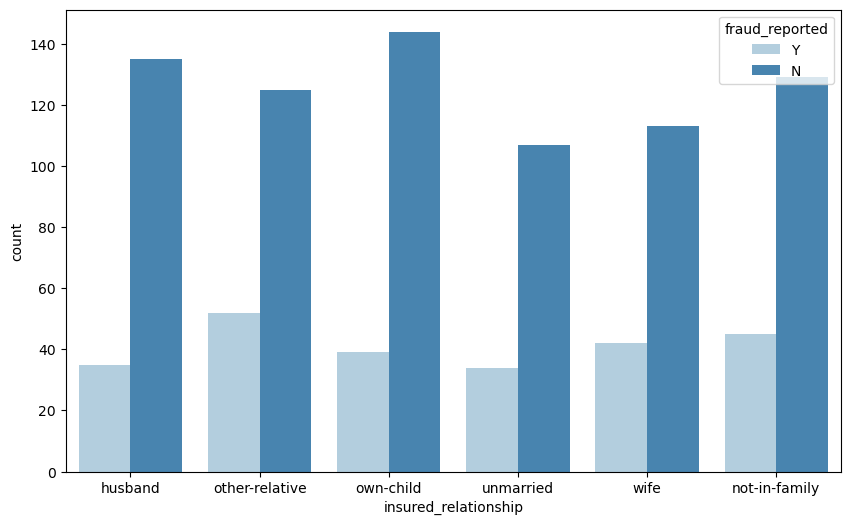

In [56]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='insured_relationship',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### capital-gains => capital_gains_yes and capital_gains_no

In [57]:
df['capital-gains'].value_counts()

capital-gains
0        508
46300      5
51500      4
68500      4
55600      3
        ... 
36700      1
54900      1
69200      1
48800      1
50300      1
Name: count, Length: 338, dtype: int64

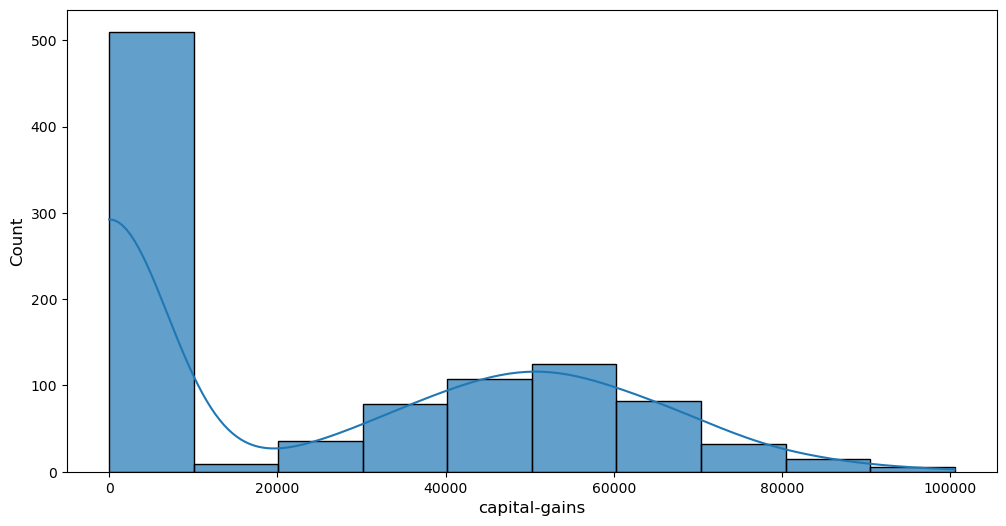

In [58]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['capital-gains'],
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('capital-gains', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [59]:
df['capital_gains_yes'] = df[df['capital-gains'] > 0]['capital-gains']
df['capital_gains_no'] = df[df['capital-gains'] == 0]['capital-gains']

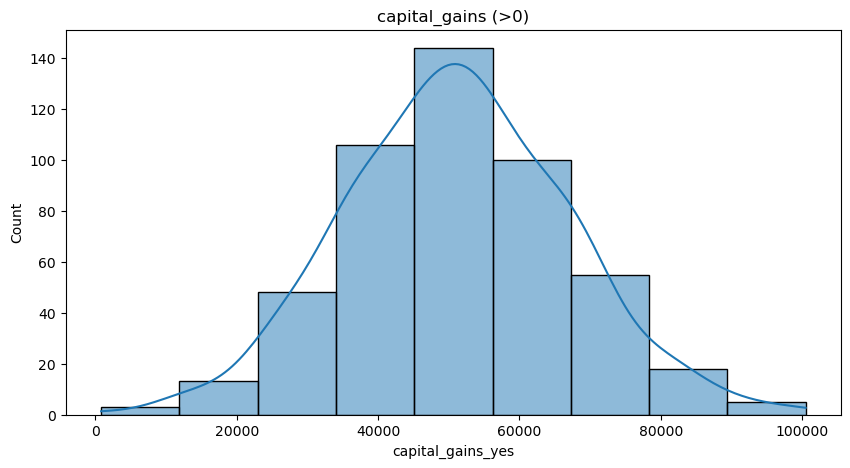

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['capital_gains_yes'],
    bins=9,
    kde=True
)

plt.title("capital_gains (>0)")
plt.show()

In [61]:
df.capital_gains_no.value_counts()

capital_gains_no
0.0    508
Name: count, dtype: int64

### capital-loss => capital_loss_yes and capital_loss_no

In [62]:
df['capital-loss'].value_counts()

capital-loss
 0        475
-31700      5
-53700      5
-50300      5
-45300      4
         ... 
-12100      1
-17000      1
-72900      1
-19700      1
-82100      1
Name: count, Length: 354, dtype: int64

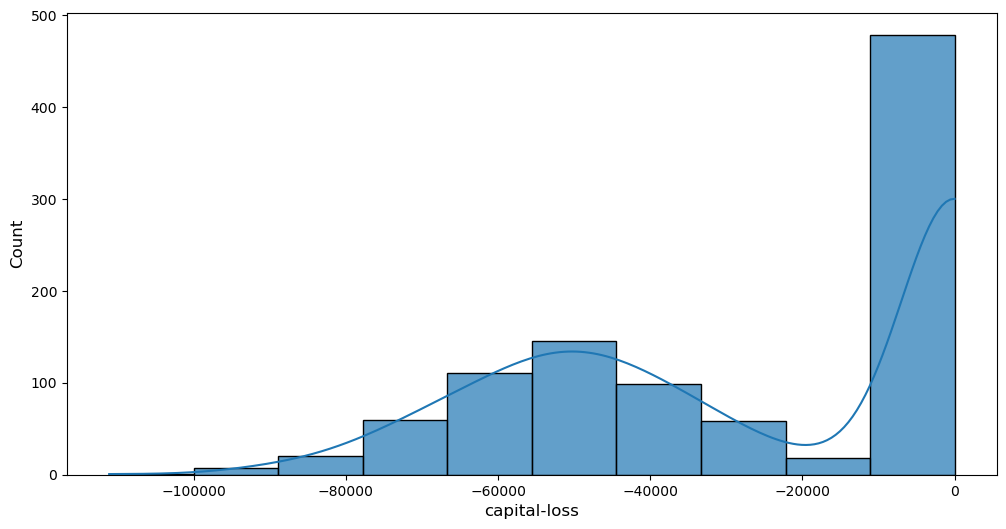

In [63]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['capital-loss'],
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('capital-loss', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [64]:
df['capital_loss_yes'] = df[df['capital-loss'] < 0]['capital-loss']
df['capital_loss_no'] = df[df['capital-loss'] == 0]['capital-loss']

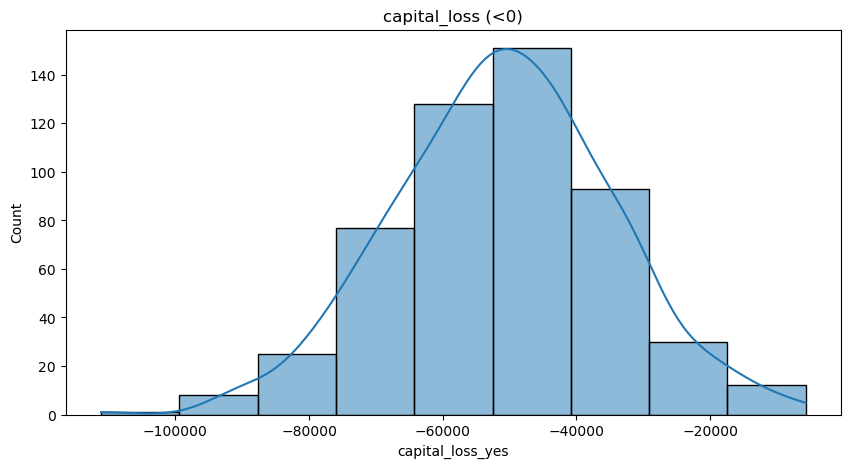

In [65]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['capital_loss_yes'],
    bins=9,
    kde=True
)

plt.title("capital_loss (<0)")
plt.show()

In [66]:
df.capital_loss_no.value_counts()

capital_loss_no
0.0    475
Name: count, dtype: int64

### incident_date => incident_day_type(看平日還是假日)

In [67]:
df["incident_date"] = pd.to_datetime(df["incident_date"])

In [68]:
df["incident_date"].head()

0   2015-01-25
1   2015-01-21
2   2015-02-22
3   2015-01-10
4   2015-02-17
Name: incident_date, dtype: datetime64[ns]

In [69]:
df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month
df["incident_weekday"] = df["incident_date"].dt.weekday

In [70]:
df["incident_year"].head()

0    2015
1    2015
2    2015
3    2015
4    2015
Name: incident_year, dtype: int32

In [71]:
df["incident_month"].head()

0    1
1    1
2    2
3    1
4    2
Name: incident_month, dtype: int32

In [72]:
df["incident_weekday"].head

<bound method NDFrame.head of 0      6
1      2
2      6
3      5
4      1
      ..
995    6
996    5
997    4
998    3
999    3
Name: incident_weekday, Length: 1000, dtype: int32>

year and month 資訊過少放掉

In [73]:
df['incident_day_type'] = df['incident_weekday'].apply(
    lambda x: 'weekday' if x < 5 else 'weekend'
)

In [74]:
pd.get_dummies(df['incident_day_type'], drop_first=True)

,weekend
0,True
1,False
2,True
3,True
4,False
...,...
995,True
996,True
997,False
998,False


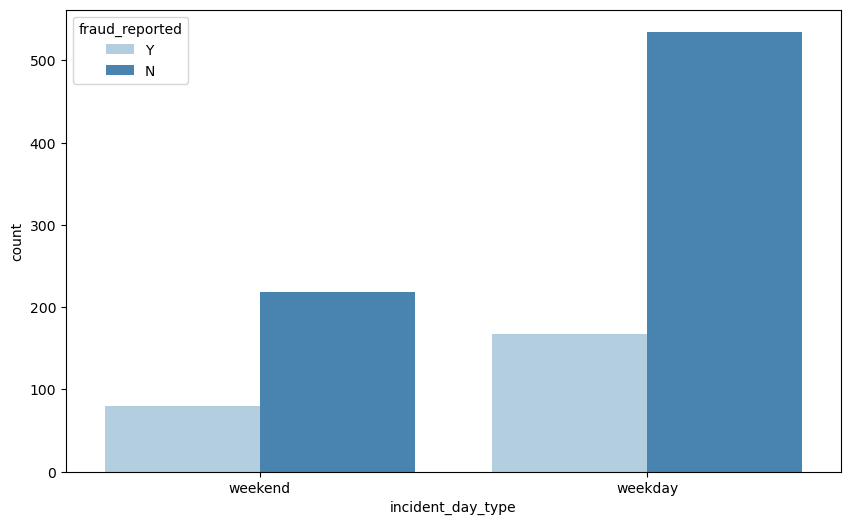

In [75]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_day_type',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

<Axes: xlabel='incident_weekday', ylabel='fraud_reported'>

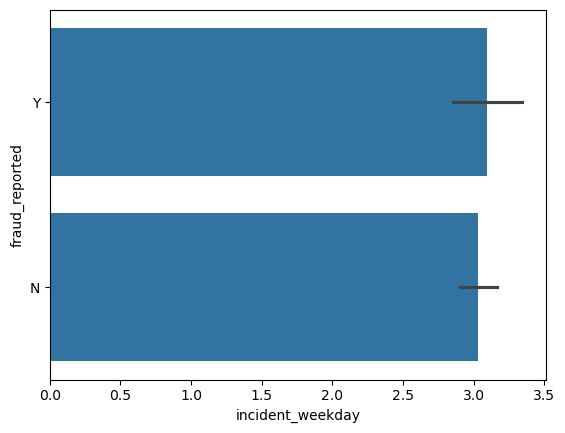

In [76]:
sns.barplot(
    x='incident_weekday',
    y='fraud_reported',
    data=df
)

### incident_type

In [77]:
df.incident_type.value_counts()

incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

In [78]:
pd.get_dummies(df.incident_type)

,Multi-vehicle Collision,Parked Car,Single Vehicle Collision,Vehicle Theft
0,False,False,True,False
1,False,False,False,True
2,True,False,False,False
3,False,False,True,False
4,False,False,False,True
...,...,...,...,...
995,False,False,True,False
996,False,False,True,False
997,True,False,False,False
998,False,False,True,False


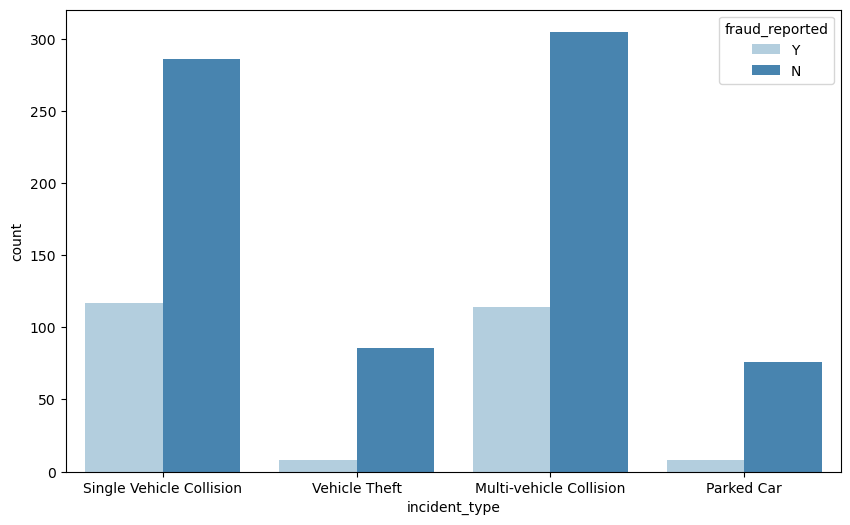

In [79]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_type',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### collision_type

In [80]:
df.collision_type.value_counts()

collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
?                  178
Name: count, dtype: int64

In [81]:
pd.get_dummies(df.collision_type)

,?,Front Collision,Rear Collision,Side Collision
0,False,False,False,True
1,True,False,False,False
2,False,False,True,False
3,False,True,False,False
4,True,False,False,False
...,...,...,...,...
995,False,True,False,False
996,False,False,True,False
997,False,False,False,True
998,False,False,True,False


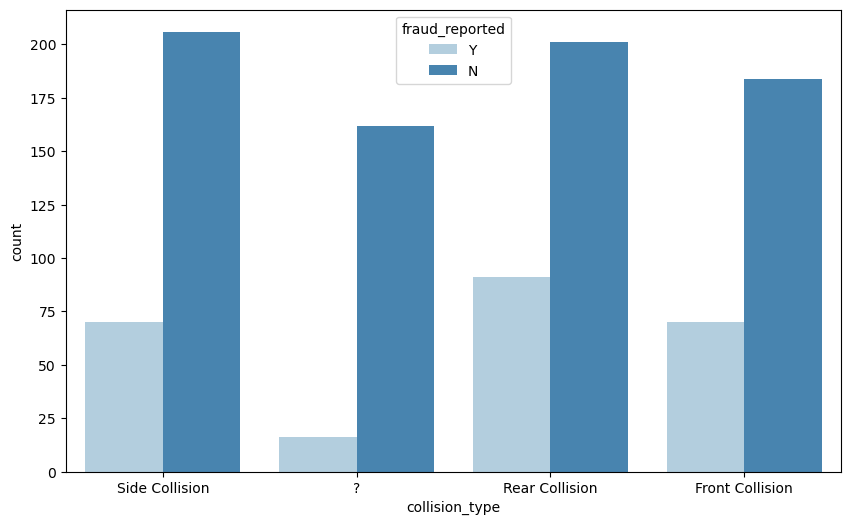

In [82]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='collision_type',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### incident_severity

In [83]:
df.incident_severity.value_counts()

incident_severity
Minor Damage      354
Total Loss        280
Major Damage      276
Trivial Damage     90
Name: count, dtype: int64

In [84]:
pd.get_dummies(df.incident_severity)

,Major Damage,Minor Damage,Total Loss,Trivial Damage
0,True,False,False,False
1,False,True,False,False
2,False,True,False,False
3,True,False,False,False
4,False,True,False,False
...,...,...,...,...
995,False,True,False,False
996,True,False,False,False
997,False,True,False,False
998,True,False,False,False


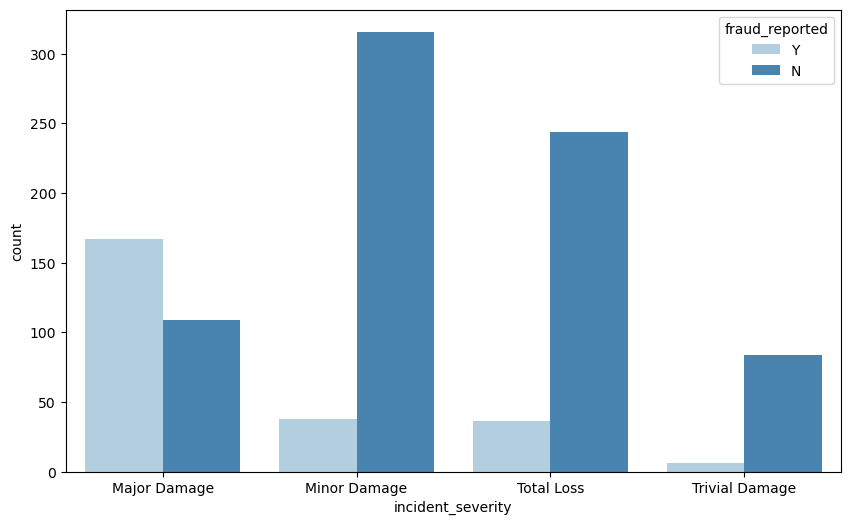

In [85]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_severity',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### authorities_contacted

In [86]:
df.authorities_contacted.value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

In [87]:
pd.get_dummies(df.authorities_contacted)

,Ambulance,Fire,Other,Police
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,False
...,...,...,...,...
995,False,True,False,False
996,False,True,False,False
997,False,False,False,True
998,False,False,True,False


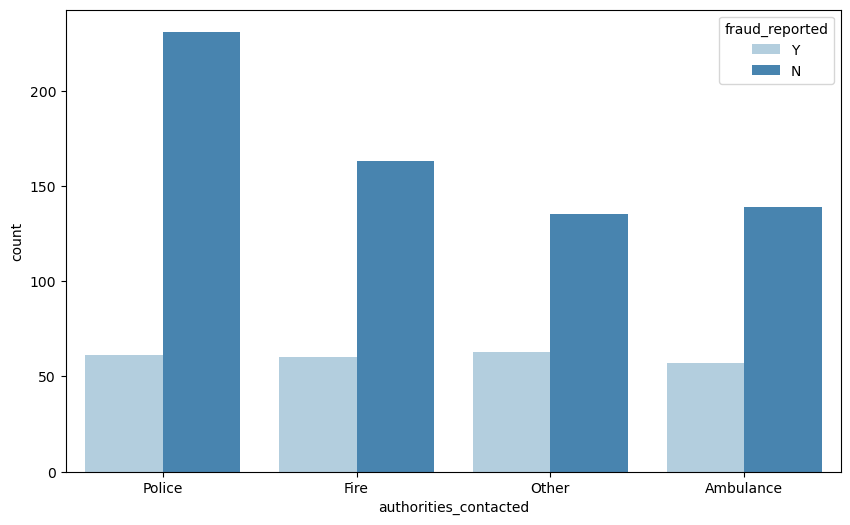

In [88]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='authorities_contacted',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### incident_state

In [89]:
df.incident_state.value_counts()

incident_state
NY    262
SC    248
WV    217
VA    110
NC    110
PA     30
OH     23
Name: count, dtype: int64

In [90]:
pd.get_dummies(df.incident_state)

,NC,NY,OH,PA,SC,VA,WV
0,False,False,False,False,True,False,False
1,False,False,False,False,False,True,False
2,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
995,True,False,False,False,False,False,False
996,False,False,False,False,True,False,False
997,True,False,False,False,False,False,False
998,False,True,False,False,False,False,False


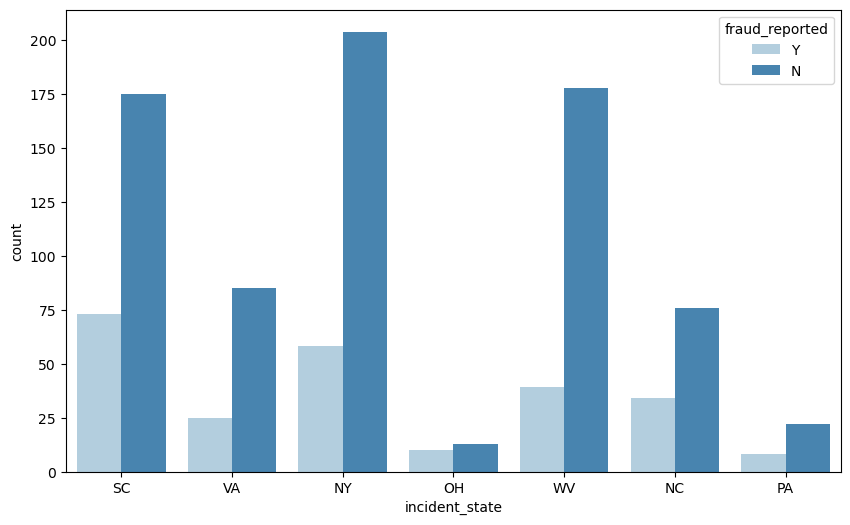

In [91]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_state',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### incident_city

In [92]:
df['incident_city'].nunique()

7

In [93]:
df.incident_city.value_counts()

incident_city
Springfield    157
Arlington      152
Columbus       149
Northbend      145
Hillsdale      141
Riverwood      134
Northbrook     122
Name: count, dtype: int64

In [94]:
pd.get_dummies(df.incident_city)

,Arlington,Columbus,Hillsdale,Northbend,Northbrook,Riverwood,Springfield
0,False,True,False,False,False,False,False
1,False,False,False,False,False,True,False
2,False,True,False,False,False,False,False
3,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,True,False,False
996,False,False,False,True,False,False,False
997,True,False,False,False,False,False,False
998,True,False,False,False,False,False,False


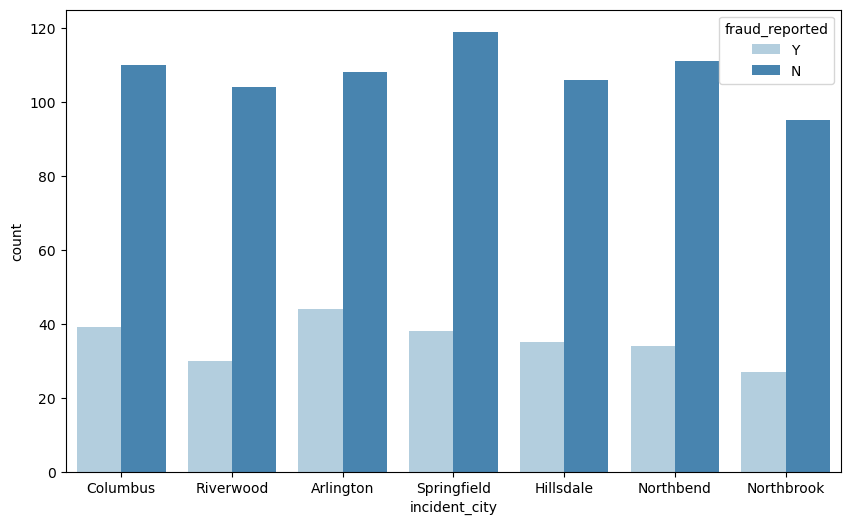

In [95]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_city',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### incident_location(X)

### incident_hour_of_the_day => incident_time_period(早中晚)

In [96]:
df['incident_time_period'] = df['incident_hour_of_the_day'].apply(
    lambda x: 'night' if x < 6 else
              'morning' if x < 12 else
              'afternoon' if x < 18 else
              'evening'
)

In [97]:
pd.get_dummies(df['incident_time_period'])

,afternoon,evening,morning,night
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,False,False,True
4,False,True,False,False
...,...,...,...,...
995,False,True,False,False
996,False,True,False,False
997,False,False,False,True
998,False,False,False,True


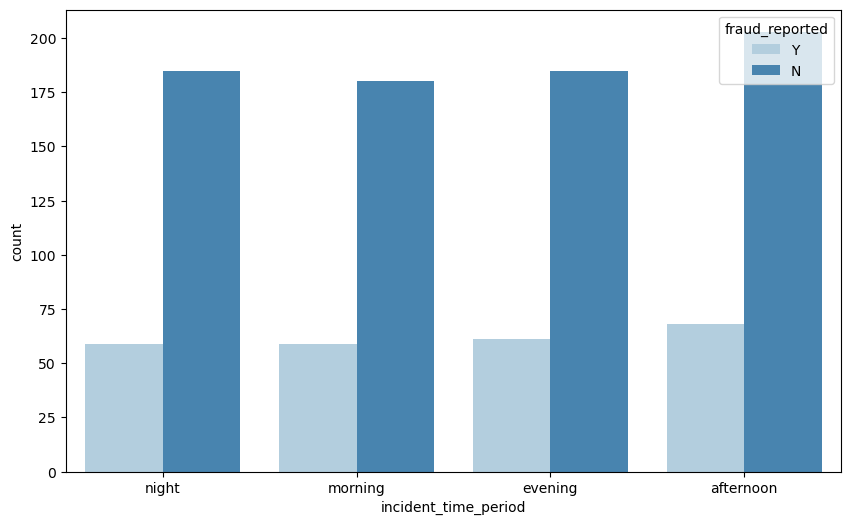

In [98]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='incident_time_period',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### number_of_vehicles_involved 

In [99]:
df.number_of_vehicles_involved.value_counts()

number_of_vehicles_involved
1    581
3    358
4     31
2     30
Name: count, dtype: int64

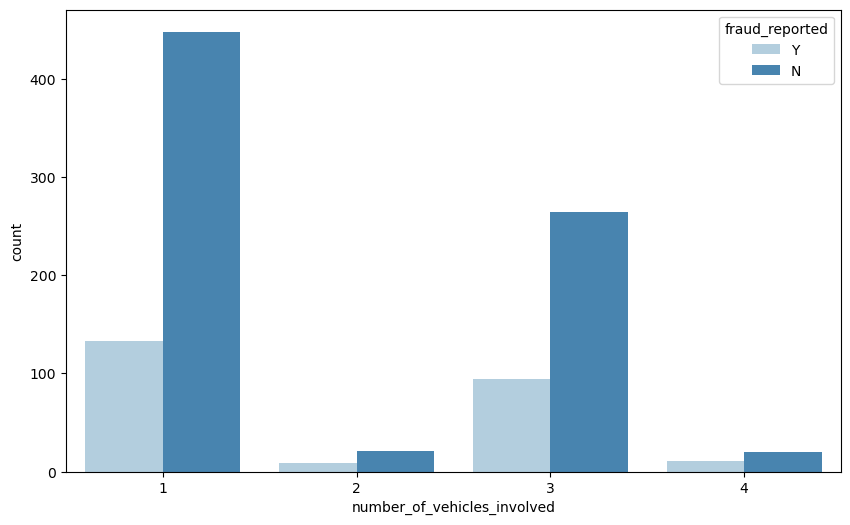

In [100]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='number_of_vehicles_involved',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### property_damage 

In [101]:
df.property_damage.value_counts()

property_damage
?      360
NO     338
YES    302
Name: count, dtype: int64

In [102]:
pd.get_dummies(df.property_damage)

,?,NO,YES
0,False,False,True
1,True,False,False
2,False,True,False
3,True,False,False
4,False,True,False
...,...,...,...
995,False,False,True
996,False,False,True
997,True,False,False
998,True,False,False


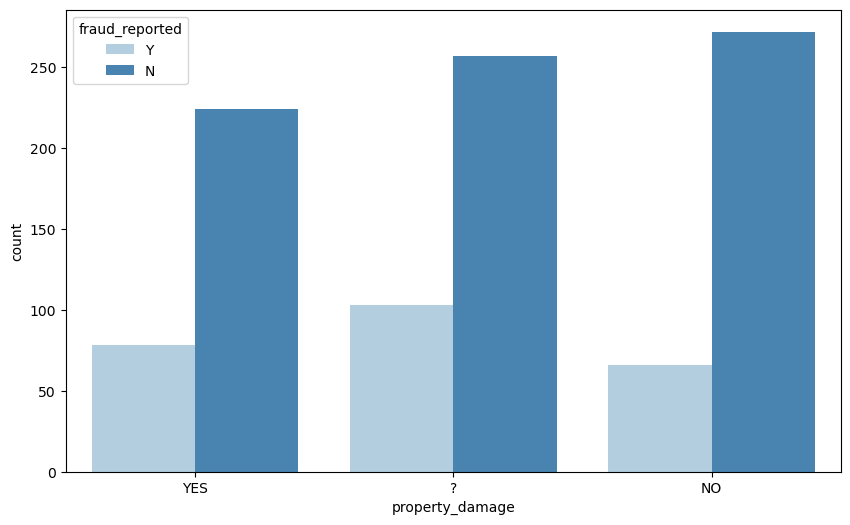

In [103]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='property_damage',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### bodily_injuries

In [104]:
df.bodily_injuries.value_counts()

bodily_injuries
0    340
2    332
1    328
Name: count, dtype: int64

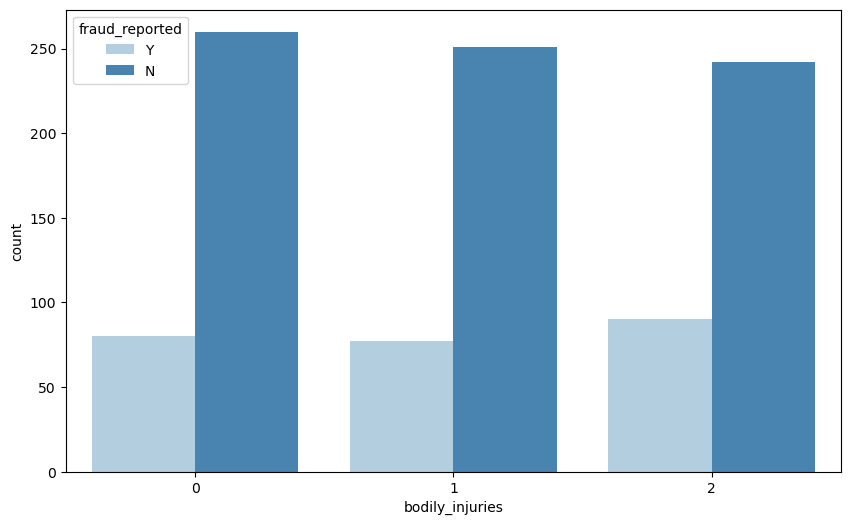

In [105]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='bodily_injuries',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### witnesses 

In [106]:
df.witnesses.value_counts()

witnesses
1    258
2    250
0    249
3    243
Name: count, dtype: int64

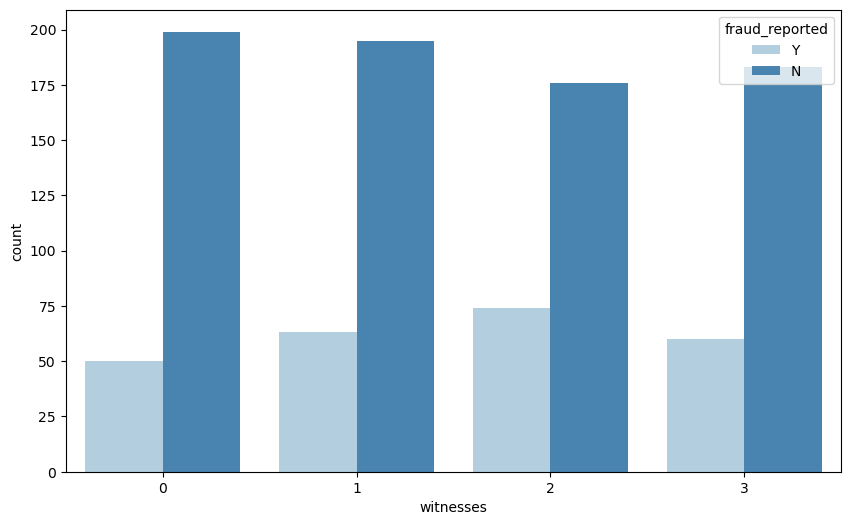

In [107]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='witnesses',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### police_report_available

In [108]:
df.police_report_available.value_counts()

police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64

In [109]:
pd.get_dummies(df.police_report_available)

,?,NO,YES
0,False,False,True
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
...,...,...,...
995,True,False,False
996,True,False,False
997,False,False,True
998,False,False,True


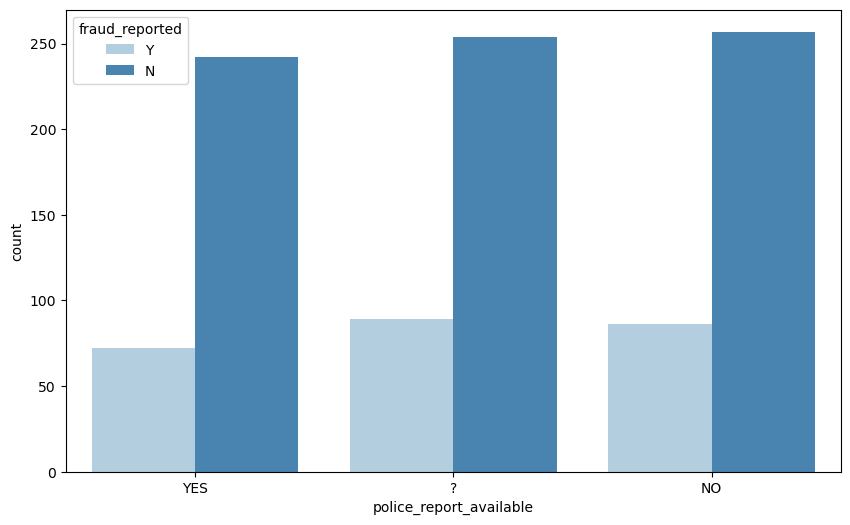

In [110]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='police_report_available',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### total_claim_amount => total_claim_level

In [111]:
df.groupby('fraud_reported')['total_claim_amount'].mean()

fraud_reported
N    50288.605578
Y    60302.105263
Name: total_claim_amount, dtype: float64

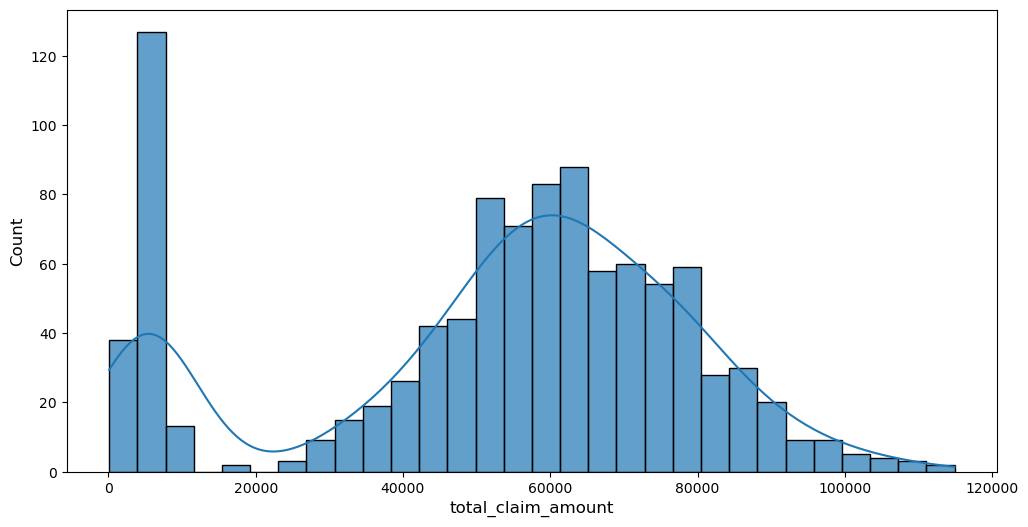

In [112]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['total_claim_amount'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('total_claim_amount', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [113]:
def total_claim_level(x):
    if x <= 15000:
        return 'low'
    else:
        return 'high'

df['total_claim_level'] = df['total_claim_amount'].apply(total_claim_level)

In [114]:
pd.get_dummies(df, columns=['total_claim_level'])

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,capital_gains_no,capital_loss_yes,capital_loss_no,incident_year,incident_month,incident_weekday,incident_day_type,incident_time_period,total_claim_level_high,total_claim_level_low
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,NaN,NaN,0.0,2015,1,6,weekend,night,True,False
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0.0,NaN,0.0,2015,1,2,weekday,morning,False,True
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NaN,NaN,0.0,2015,2,6,weekend,morning,True,False
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NaN,-62400.0,NaN,2015,1,5,weekend,night,True,False
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NaN,-46000.0,NaN,2015,2,1,weekday,evening,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,0.0,NaN,0.0,2015,2,6,weekend,evening,True,False
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,NaN,NaN,0.0,2015,1,5,weekend,evening,True,False
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,NaN,NaN,0.0,2015,1,4,weekday,night,True,False
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,0.0,NaN,0.0,2015,2,3,weekday,night,True,False


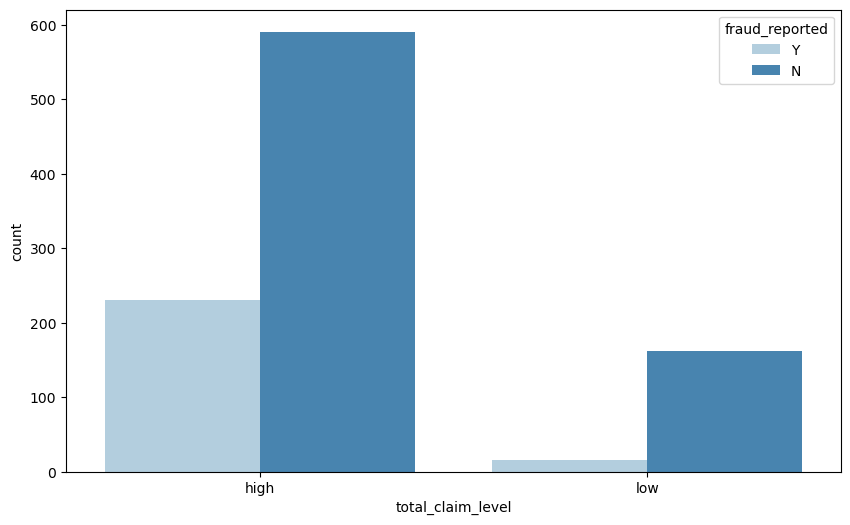

In [115]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='total_claim_level',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### injury_claim => injury_claim_level

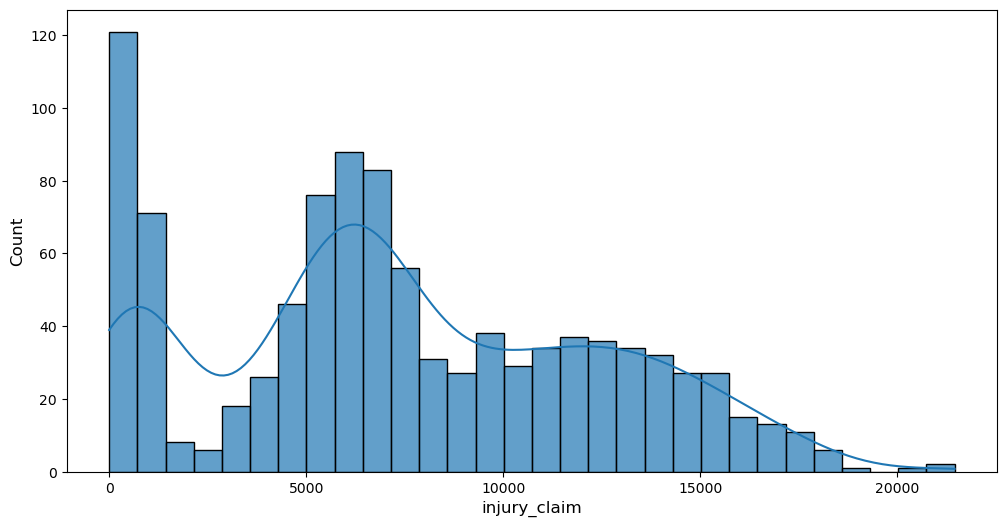

In [116]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['injury_claim'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('injury_claim', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [117]:
def injury_claim_level(x):
    if x <= 2000:
        return 'low'
    elif x <= 6000:
        return 'mid'
    else:
        return 'high'

df['injury_claim_level'] = df['injury_claim'].apply(injury_claim_level)

In [118]:
pd.get_dummies(df, columns=['injury_claim_level'])

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,capital_loss_no,incident_year,incident_month,incident_weekday,incident_day_type,incident_time_period,total_claim_level,injury_claim_level_high,injury_claim_level_low,injury_claim_level_mid
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,0.0,2015,1,6,weekend,night,high,True,False,False
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0.0,2015,1,2,weekday,morning,low,False,True,False
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,0.0,2015,2,6,weekend,morning,high,True,False,False
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NaN,2015,1,5,weekend,night,high,True,False,False
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NaN,2015,2,1,weekday,evening,low,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,0.0,2015,2,6,weekend,evening,high,True,False,False
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,0.0,2015,1,5,weekend,evening,high,True,False,False
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,0.0,2015,1,4,weekday,night,high,True,False,False
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,0.0,2015,2,3,weekday,night,high,False,False,True


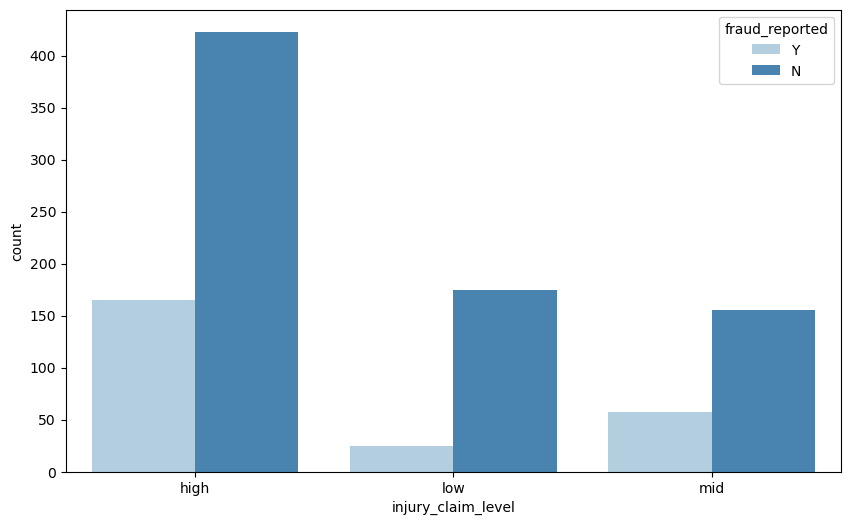

In [119]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='injury_claim_level',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### property_claim => property_claim_level

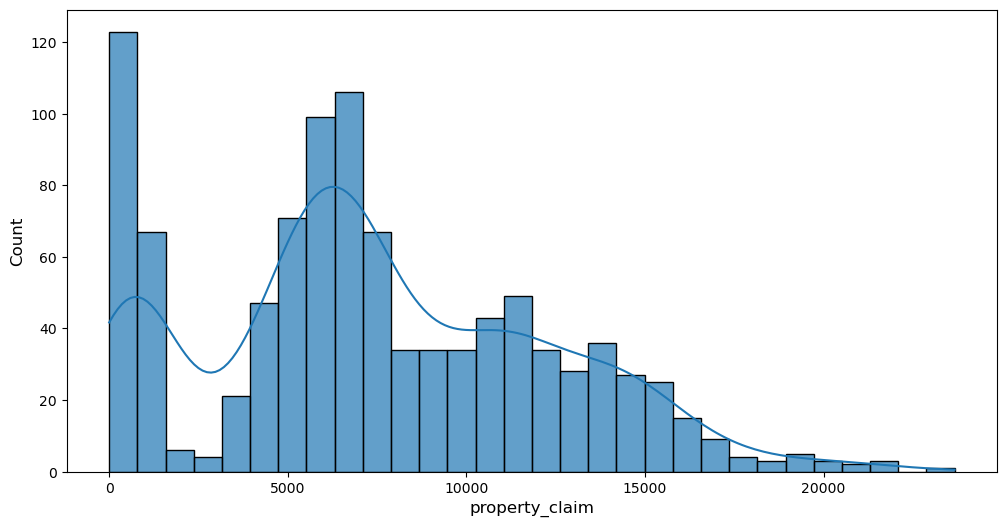

In [120]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['property_claim'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('property_claim', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [121]:
def property_claim_level(x):
    if x <= 3500:
        return 'low'
    elif x <= 10000:
        return 'mid'
    else:
        return 'high'

df['property_claim_level'] = df['property_claim'].apply(property_claim_level)

In [122]:
pd.get_dummies(df, columns=['property_claim_level'])

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,incident_year,incident_month,incident_weekday,incident_day_type,incident_time_period,total_claim_level,injury_claim_level,property_claim_level_high,property_claim_level_low,property_claim_level_mid
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2015,1,6,weekend,night,high,high,True,False,False
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,2015,1,2,weekday,morning,low,low,False,True,False
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,2015,2,6,weekend,morning,high,high,False,False,True
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2015,1,5,weekend,night,high,high,False,False,True
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,2015,2,1,weekday,evening,low,low,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,2015,2,6,weekend,evening,high,high,False,False,True
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,2015,1,5,weekend,evening,high,high,True,False,False
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,2015,1,4,weekday,night,high,high,False,False,True
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,2015,2,3,weekday,night,high,mid,False,False,True


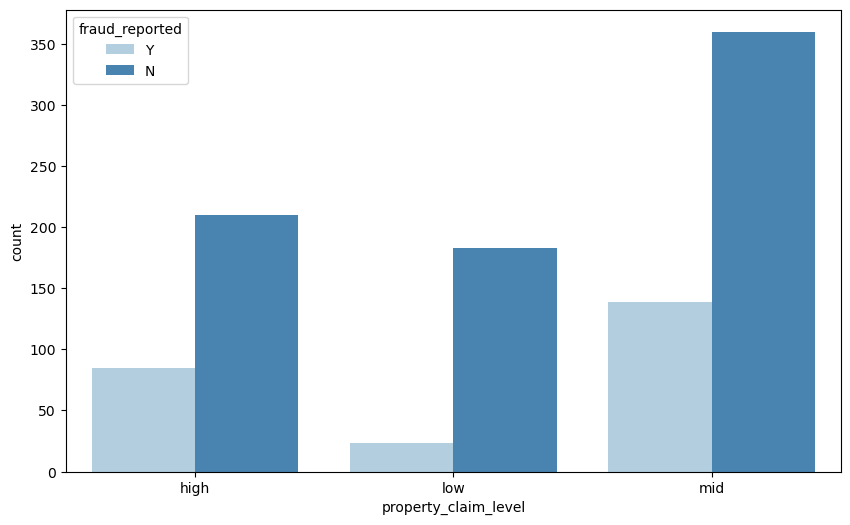

In [123]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='property_claim_level',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### vehicle_claim => vehicle_claim_level

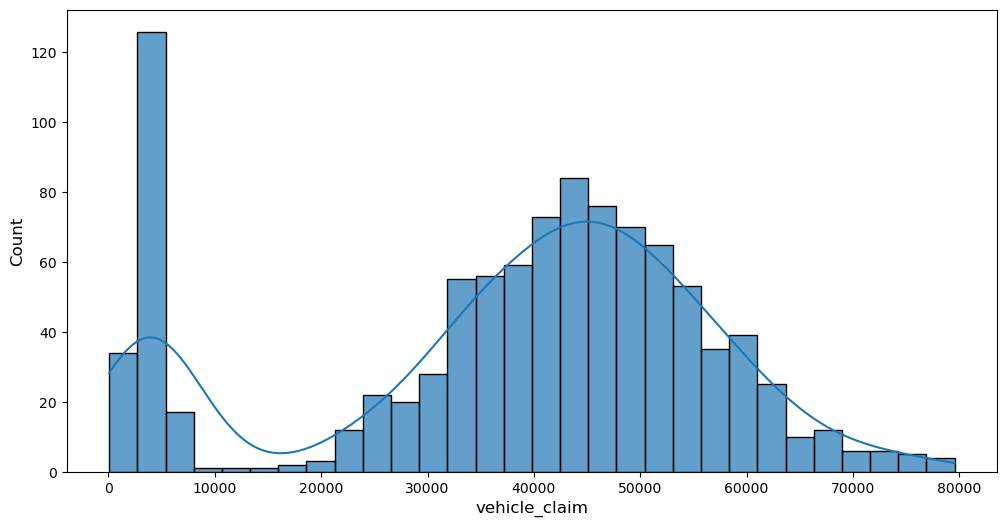

In [124]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['vehicle_claim'],
    bins=30,
    kde=True,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('vehicle_claim', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [125]:
def vehicle_claim_level(x):
    if x <= 15000:
        return 'low'
    else:
        return 'high'

df['vehicle_claim_level'] = df['vehicle_claim'].apply(vehicle_claim_level)

In [126]:
pd.get_dummies(df, columns=['vehicle_claim_level'])

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,incident_year,incident_month,incident_weekday,incident_day_type,incident_time_period,total_claim_level,injury_claim_level,property_claim_level,vehicle_claim_level_high,vehicle_claim_level_low
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2015,1,6,weekend,night,high,high,high,True,False
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,2015,1,2,weekday,morning,low,low,low,False,True
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,2015,2,6,weekend,morning,high,high,mid,True,False
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2015,1,5,weekend,night,high,high,mid,True,False
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,2015,2,1,weekday,evening,low,low,low,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,2015,2,6,weekend,evening,high,high,mid,True,False
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,2015,1,5,weekend,evening,high,high,high,True,False
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,2015,1,4,weekday,night,high,high,mid,True,False
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,2015,2,3,weekday,night,high,mid,mid,True,False


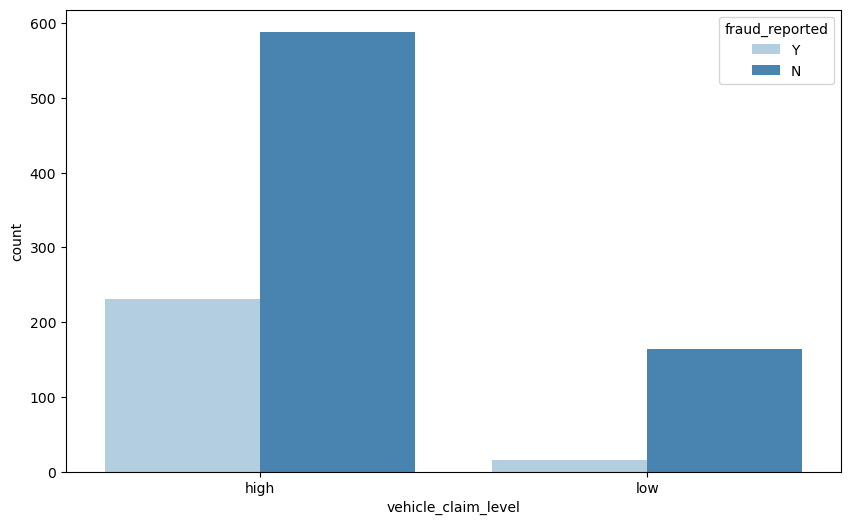

In [127]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='vehicle_claim_level',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### auto_make 

In [128]:
pd.get_dummies(df, columns=['auto_make'])

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,auto_make_Dodge,auto_make_Ford,auto_make_Honda,auto_make_Jeep,auto_make_Mercedes,auto_make_Nissan,auto_make_Saab,auto_make_Suburu,auto_make_Toyota,auto_make_Volkswagen
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,False,False,False,False,False,False,True,False,False,False
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,False,False,False,False,True,False,False,False,False,False
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,True,False,False,False,False,False,False,False,False,False
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,False,False,False,False,False,False,False,False,False,False
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,False,False,True,False,False,False,False,False,False,False
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,False,False,False,False,False,False,False,False,False,True
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,False,False,False,False,False,False,False,True,False,False
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,False,False,False,False,False,False,False,False,False,False


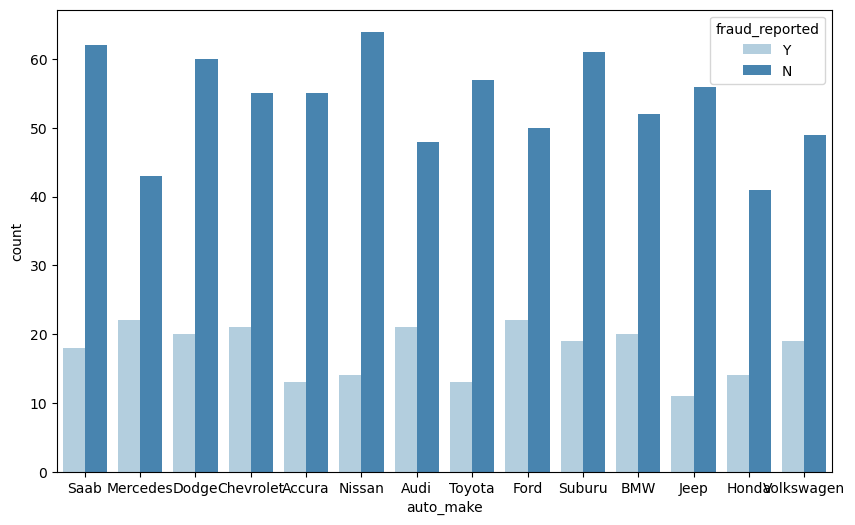

In [129]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='auto_make',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### auto_model(X)

### auto_year => vehicle_age

In [130]:
df['vehicle_age'] = df['incident_year'] - df['auto_year']

In [131]:
df['vehicle_age'].describe()

count    1000.000000
mean        9.897000
std         6.015861
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: vehicle_age, dtype: float64

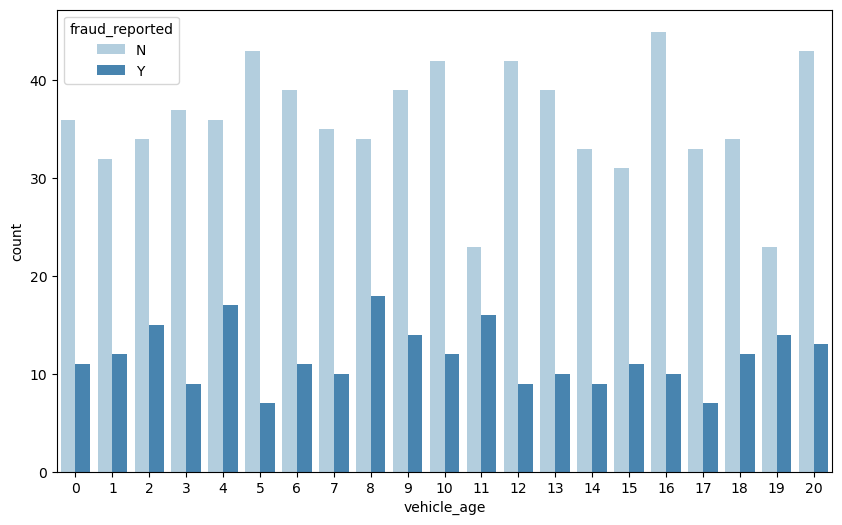

In [132]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='vehicle_age',
    data=df,
    palette='Blues',
    hue='fraud_reported'
)

plt.show()

### fraud_reported 目標變數

## 資料初步篩選

In [133]:
df.describe(include='all')

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,incident_year,incident_month,incident_weekday,incident_day_type,incident_time_period,total_claim_level,injury_claim_level,property_claim_level,vehicle_claim_level,vehicle_age
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1.000000e+03,1000.000000,...,1000.0,1000.000000,1000.00000,1000,1000,1000,1000,1000,1000,1000.000000
unique,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2,4,2,3,3,2,NaN
top,NaN,NaN,NaN,NaN,OH,250/500,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,weekday,afternoon,high,high,mid,high,NaN
freq,NaN,NaN,NaN,NaN,352,351,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,702,271,822,588,499,820,NaN
mean,203.954000,38.948000,546238.648000,2002-02-08 04:40:47.999999872,NaN,NaN,1136.000000,1256.406150,1.101000e+06,501214.488000,...,2015.0,1.496000,3.04700,NaN,NaN,NaN,NaN,NaN,NaN,9.897000
min,0.000000,19.000000,100804.000000,1990-01-08 00:00:00,NaN,NaN,500.000000,433.330000,-1.000000e+06,430104.000000,...,2015.0,1.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,115.750000,32.000000,335980.250000,1995-09-19 00:00:00,NaN,NaN,500.000000,1089.607500,0.000000e+00,448404.500000,...,2015.0,1.000000,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,199.500000,38.000000,533135.000000,2002-04-01 12:00:00,NaN,NaN,1000.000000,1257.200000,0.000000e+00,466445.500000,...,2015.0,1.000000,3.00000,NaN,NaN,NaN,NaN,NaN,NaN,10.000000
75%,276.250000,44.000000,759099.750000,2008-04-21 12:00:00,NaN,NaN,2000.000000,1415.695000,0.000000e+00,603251.000000,...,2015.0,2.000000,5.00000,NaN,NaN,NaN,NaN,NaN,NaN,15.000000
max,479.000000,64.000000,999435.000000,2015-02-22 00:00:00,NaN,NaN,2000.000000,2047.590000,1.000000e+07,620962.000000,...,2015.0,3.000000,6.00000,NaN,NaN,NaN,NaN,NaN,NaN,20.000000


In [134]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

Column choice

(O) 0   months_as_customer           1000 non-null   int64         
(O) 1   age                          1000 non-null   int64         
(X) 2   policy_number                1000 non-null   int64         
(X) 3   policy_bind_date             1000 non-null   datetime64
(O) 4   policy_state                 1000 non-null   object        
(X) 5   policy_csl                   1000 non-null   object        
(O) 6   policy_deductable            1000 non-null   int64         
(O) 7   policy_annual_premium        1000 non-null   float64       
(X) 8   umbrella_limit               1000 non-null   int64         
(X) 9   insured_zip                  1000 non-null   int64         
(O) 10  insured_sex                  1000 non-null   object        
(O) 11  insured_education_level      1000 non-null   object        
(O) 12  insured_occupation           1000 non-null   object        
(O) 13  insured_hobbies              1000 non-null   object        
(O) 14  insured_relationship         1000 non-null   object        
(X) 15  capital-gains                1000 non-null   int64         
(X) 16  capital-loss                 1000 non-null   int64         
(X) 17  incident_date                1000 non-null   datetime64
(O) 18  incident_type                1000 non-null   object        
(O) 19  collision_type               1000 non-null   object        
(O) 20  incident_severity            1000 non-null   object        
(O) 21  authorities_contacted        909 non-null    object        
(O) 22  incident_state               1000 non-null   object        
(O) 23  incident_city                1000 non-null   object        
(X) 24  incident_location            1000 non-null   object        
(X) 25  incident_hour_of_the_day     1000 non-null   int64         
(O) 26  number_of_vehicles_involved  1000 non-null   int64         
(O) 27  property_damage              1000 non-null   object        
(O) 28  bodily_injuries              1000 non-null   int64         
(O) 29  witnesses                    1000 non-null   int64         
(O) 30  police_report_available      1000 non-null   object        
(X) 31  total_claim_amount           1000 non-null   int64         
(X) 32  injury_claim                 1000 non-null   int64         
(X) 33  property_claim               1000 non-null   int64         
(X) 34  vehicle_claim                1000 non-null   int64         
(O) 35  auto_make                    1000 non-null   object        
(X) 36  auto_model                   1000 non-null   object        
(X) 37  auto_year                    1000 non-null   int64         
(O) 38  fraud_reported               1000 non-null   object        
(X) 39  _c39                         0 non-null      float64       
(O) 40  policy_bind_year             1000 non-null   int32         
(O) 41  policy_bind_month            1000 non-null   int32         
(O) 42  policy_bind_weekday          1000 non-null   int32         
(O) 43  csl_person                   1000 non-null   int64         
(O) 44  csl_accident                 1000 non-null   int64         
(O) 45  umbrella_limit_yes           201 non-null    float64       
(X) 46  umbrella_limit_no            798 non-null    float64       
(O) 47  capital_gains_yes            492 non-null    float64       
(X) 48  capital_gains_no             508 non-null    float64       
(O) 49  capital_loss_yes             525 non-null    float64       
(X) 50  capital_loss_no              475 non-null    float64       
(X) 51  incident_year                1000 non-null   int32         
(X) 52  incident_month               1000 non-null   int32         
(X) 53  incident_weekday             1000 non-null   int32         
(O) 54  incident_day_type            1000 non-null   object        
(O) 55  incident_time_period         1000 non-null   object        
(X) 56  total_claim_level            1000 non-null   object        
(O) 57  injury_claim_level           1000 non-null   object        
(O) 58  property_claim_level         1000 non-null   object        
(O) 59  vehicle_claim_level          1000 non-null   object        
(O) 60  vehicle_age                  1000 non-null   int64         
dtypes: datetime64[ns](2), float64(8), int32(6), int64(20), object(25)
memory usage: 453.3+ KB

In [135]:
df = df.drop(columns=[
    'policy_number',
    'policy_bind_date',
    'policy_csl',
    'umbrella_limit',
    'insured_zip',
    'capital-gains',
    'capital-loss',
    'incident_date',
    'incident_location',
    'incident_hour_of_the_day',
    'total_claim_amount',
    'injury_claim',
    'property_claim',
    'vehicle_claim',
    'auto_model',
    'auto_year',
    '_c39',
    'policy_bind_year',
    'policy_bind_weekday',
    'umbrella_limit_no',
    'capital_gains_no',
    'capital_loss_no',
    'incident_year',
    'incident_month',
    'incident_weekday',
    'total_claim_level'
])

In [136]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   object 
 3   policy_deductable            1000 non-null   int64  
 4   policy_annual_premium        1000 non-null   float64
 5   insured_sex                  1000 non-null   object 
 6   insured_education_level      1000 non-null   object 
 7   insured_occupation           1000 non-null   object 
 8   insured_hobbies              1000 non-null   object 
 9   insured_relationship         1000 non-null   object 
 10  incident_type                1000 non-null   object 
 11  collision_type               1000 non-null   object 
 12  incident_severity            1000 non-null   object 
 13  authorities_contact

## 資料分類 cat and num

In [137]:
numeric_features = [
    'months_as_customer',
    'age',
    'policy_annual_premium',
    'policy_deductable',
    'number_of_vehicles_involved',
    'bodily_injuries',
    'witnesses',
    'vehicle_age',
    'umbrella_limit_yes',
    'capital_gains_yes',
    'capital_loss_yes'
]

categorical_features = [
    'policy_state',
    'insured_sex',
    'insured_education_level',
    'insured_occupation',
    'insured_hobbies',
    'insured_relationship',
    'incident_type',
    'collision_type',
    'incident_severity',
    'authorities_contacted',
    'incident_state',
    'incident_city',
    'property_damage',
    'police_report_available',
    'auto_make',
    'policy_bind_daytype',
    'incident_day_type',
    'incident_time_period',
    'injury_claim_level',
    'property_claim_level',
    'vehicle_claim_level',
    #  這些雖然是數字，但本質是類別
    'policy_bind_month',
    'csl_person',
    'csl_accident'
]

## Heat Map

In [138]:
from sklearn.preprocessing import LabelEncoder

In [139]:
df_heat = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# encode categorical
for col in categorical_features:
    df_heat[col] = df_heat[col].astype(str)
    df_heat[col] = le.fit_transform(df_heat[col])

df_heat['fraud_reported'] = df_heat['fraud_reported'].map({'N':0, 'Y':1})

heat_features = numeric_features + categorical_features + ['fraud_reported']

df_heat = df_heat[heat_features]

In [140]:
corr = df_heat.corr()

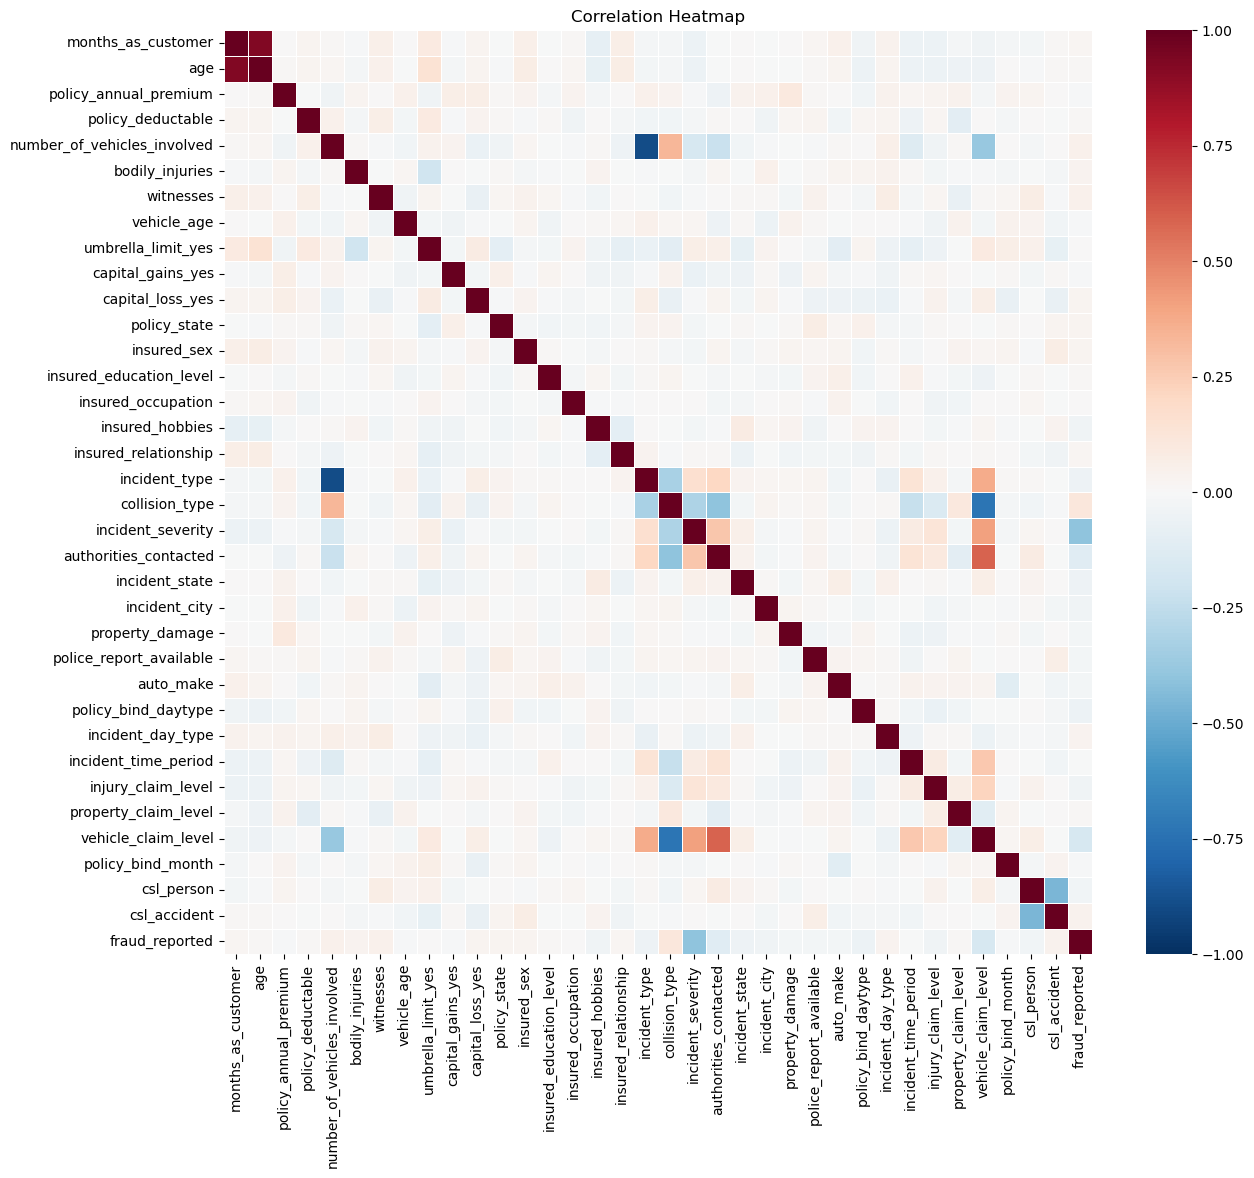

In [141]:
plt.figure(figsize=(14,12))

sns.heatmap(
    corr,
    cmap="RdBu_r",     
    center=0,          
    vmax=1,
    vmin=-1,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [142]:
corr = df_heat.corr()

fraud_corr = corr['fraud_reported'].sort_values(ascending=False)

# 只留重要的（絕對值 > 0.1）
fraud_corr = fraud_corr[abs(fraud_corr) > 0.1]

print(fraud_corr)

fraud_reported           1.000000
collision_type           0.110130
authorities_contacted   -0.119702
vehicle_claim_level     -0.171769
incident_severity       -0.405988
Name: fraud_reported, dtype: float64


In [143]:
df[['months_as_customer','age']].corr()

,months_as_customer,age
months_as_customer,1.000000,0.922098
age,0.922098,1.000000


In [144]:
df[['csl_person','csl_accident']].corr()

,csl_person,csl_accident
csl_person,1.000000,0.994652
csl_accident,0.994652,1.000000


### 結論 month as customer and age 與 csl_person and asl_accident 保留一個

In [145]:
df = df.drop(columns=[
  'months_as_customer',
    'csl_person'
])

In [146]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1000 non-null   int64  
 1   policy_state                 1000 non-null   object 
 2   policy_deductable            1000 non-null   int64  
 3   policy_annual_premium        1000 non-null   float64
 4   insured_sex                  1000 non-null   object 
 5   insured_education_level      1000 non-null   object 
 6   insured_occupation           1000 non-null   object 
 7   insured_hobbies              1000 non-null   object 
 8   insured_relationship         1000 non-null   object 
 9   incident_type                1000 non-null   object 
 10  collision_type               1000 non-null   object 
 11  incident_severity            1000 non-null   object 
 12  authorities_contacted        909 non-null    object 
 13  incident_state     

In [147]:
numeric_features = [
    'age',
    'policy_annual_premium',
    'policy_deductable',
    'number_of_vehicles_involved',
    'bodily_injuries',
    'witnesses',
    'vehicle_age',
    'umbrella_limit_yes',
    'capital_gains_yes',
    'capital_loss_yes'
]

categorical_features = [
    'policy_state',
    'insured_sex',
    'insured_education_level',
    'insured_occupation',
    'insured_hobbies',
    'insured_relationship',
    'incident_type',
    'collision_type',
    'incident_severity',
    'authorities_contacted',
    'incident_state',
    'incident_city',
    'property_damage',
    'police_report_available',
    'auto_make',
    'policy_bind_daytype',
    'incident_day_type',
    'incident_time_period',
    'injury_claim_level',
    'property_claim_level',
    'vehicle_claim_level',
    #  這些雖然是數字，但本質是類別
    'policy_bind_month',
    'csl_accident'
]

## 建模前準備

In [148]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df[numeric_features + categorical_features]
y = df['fraud_reported'].map({'N': 0, 'Y': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [149]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = list(skf.split(X_train, y_train))

In [150]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [151]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## XGBoost

In [152]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [153]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

xgb_y_true_cv = []
xgb_y_pred_cv = []
xgb_y_prob_cv = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"===== Fold {fold} =====")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    xgb_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ])

    xgb_pipe.fit(X_tr, y_tr)

    y_pred = xgb_pipe.predict(X_val)
    y_prob = xgb_pipe.predict_proba(X_val)[:, 1]

    xgb_y_true_cv.extend(y_val)
    xgb_y_pred_cv.extend(y_pred)
    xgb_y_prob_cv.extend(y_prob)

===== Fold 1 =====
===== Fold 2 =====
===== Fold 3 =====
===== Fold 4 =====
===== Fold 5 =====


CV

In [154]:
print("XGBoost CV Results")
print("Accuracy:", accuracy_score(xgb_y_true_cv, xgb_y_pred_cv))
print("Precision:", precision_score(xgb_y_true_cv, xgb_y_pred_cv))
print("Recall:", recall_score(xgb_y_true_cv, xgb_y_pred_cv))
print("F1:", f1_score(xgb_y_true_cv, xgb_y_pred_cv))
print("AUC:", roc_auc_score(xgb_y_true_cv, xgb_y_prob_cv))

XGBoost CV Results
Accuracy: 0.84
Precision: 0.6822916666666666
Recall: 0.6616161616161617
F1: 0.6717948717948717
AUC: 0.8648444578677137


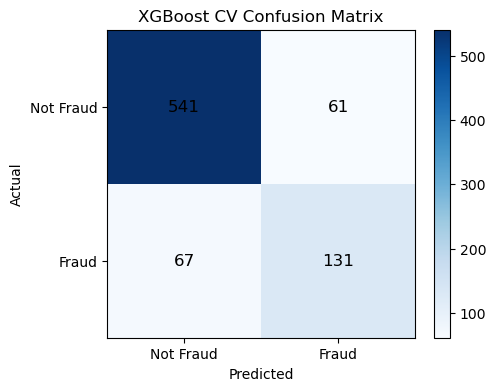

In [155]:
import matplotlib.pyplot as plt

cm_xgb_cv = confusion_matrix(xgb_y_true_cv, xgb_y_pred_cv)

plt.figure(figsize=(5,4))
plt.imshow(cm_xgb_cv, cmap="Blues")
plt.title("XGBoost CV Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_xgb_cv[i, j], ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

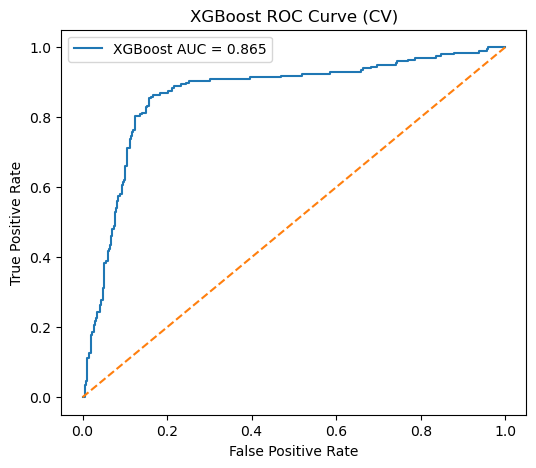

In [156]:
from sklearn.metrics import roc_curve, auc

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(xgb_y_true_cv, xgb_y_prob_cv)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve (CV)")
plt.legend()
plt.show()

In [157]:
final_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

final_xgb.fit(X_train, y_train)

xgb_test_pred = final_xgb.predict(X_test)
xgb_test_prob = final_xgb.predict_proba(X_test)[:, 1]

In [158]:
print("XGBoost Test Results")
print("Accuracy:", accuracy_score(y_test, xgb_test_pred))
print("Precision:", precision_score(y_test, xgb_test_pred))
print("Recall:", recall_score(y_test, xgb_test_pred))
print("F1:", f1_score(y_test, xgb_test_pred))
print("AUC:", roc_auc_score(y_test, xgb_test_prob))

XGBoost Test Results
Accuracy: 0.77
Precision: 0.5428571428571428
Recall: 0.3877551020408163
F1: 0.4523809523809524
AUC: 0.8159210704149209


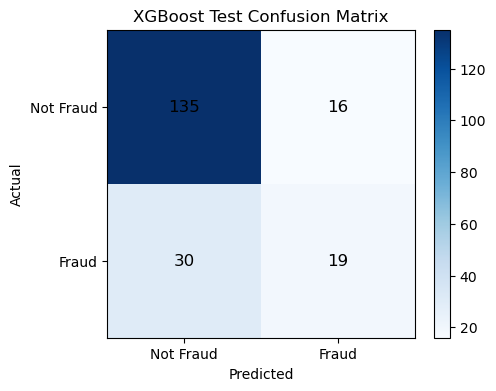

In [159]:
cm_xgb_test = confusion_matrix(y_test, xgb_test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm_xgb_test, cmap="Blues")
plt.title("XGBoost Test Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_xgb_test[i, j],
                 ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

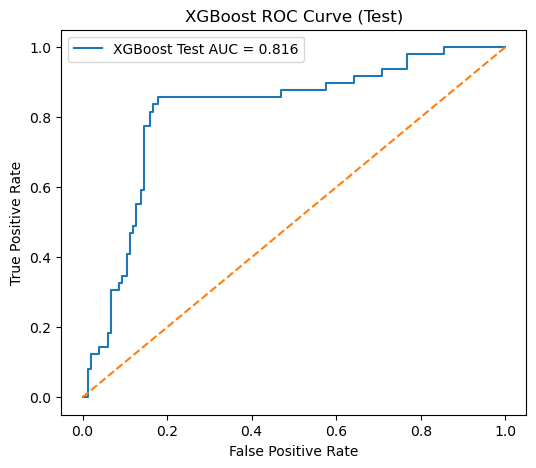

In [160]:
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test, xgb_test_prob)
roc_auc_test_xgb = auc(fpr_test_xgb, tpr_test_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_test_xgb, tpr_test_xgb, label=f"XGBoost Test AUC = {roc_auc_test_xgb:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve (Test)")
plt.legend()
plt.show()

XGBoost 模型在交叉驗證中達到 AUC 0.865，在測試資料上為 0.816，顯示模型具有良好的預測能力。雖然測試表現略低於訓練過程，但差距約 0.05，屬於可接受範圍，顯示模型具備一定泛化能力。

## 神經網路

In [161]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

nn_y_true_cv = []
nn_y_pred_cv = []
nn_y_prob_cv = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"===== Fold {fold} =====")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    nn_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64,32),
            max_iter=500,
            random_state=42
        ))
    ])

    nn_pipe.fit(X_tr, y_tr)

    y_pred = nn_pipe.predict(X_val)
    y_prob = nn_pipe.predict_proba(X_val)[:, 1]

    nn_y_true_cv.extend(y_val)
    nn_y_pred_cv.extend(y_pred)
    nn_y_prob_cv.extend(y_prob)

===== Fold 1 =====
===== Fold 2 =====
===== Fold 3 =====
===== Fold 4 =====
===== Fold 5 =====


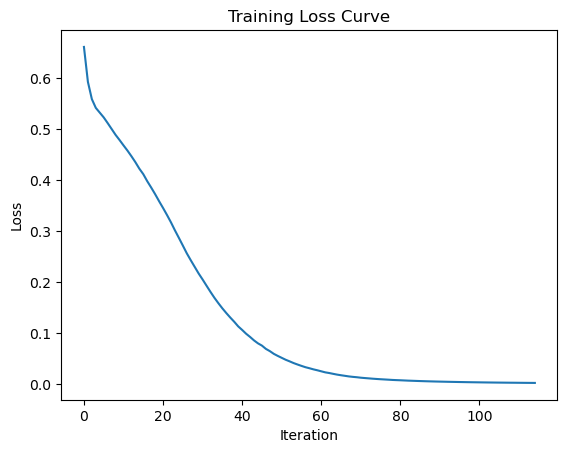

In [162]:
plt.plot(nn_pipe.named_steps['model'].loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [163]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Neural Network CV Results")
print("Accuracy:", accuracy_score(nn_y_true_cv, nn_y_pred_cv))
print("Precision:", precision_score(nn_y_true_cv, nn_y_pred_cv))
print("Recall:", recall_score(nn_y_true_cv, nn_y_pred_cv))
print("F1:", f1_score(nn_y_true_cv, nn_y_pred_cv))
print("AUC:", roc_auc_score(nn_y_true_cv, nn_y_prob_cv))

Neural Network CV Results
Accuracy: 0.795
Precision: 0.6133333333333333
Recall: 0.46464646464646464
F1: 0.5287356321839081
AUC: 0.8222004094097116


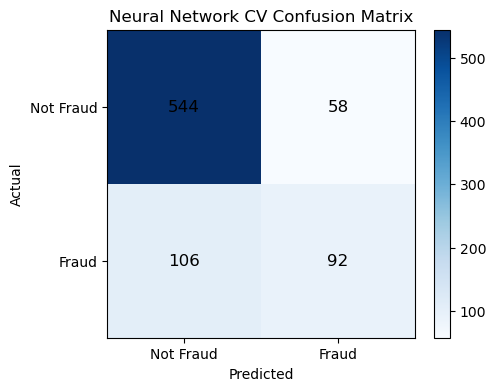

In [164]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_nn_cv = confusion_matrix(nn_y_true_cv, nn_y_pred_cv)

plt.figure(figsize=(5,4))
plt.imshow(cm_nn_cv, cmap="Blues")
plt.title("Neural Network CV Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nn_cv[i, j],
                 ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

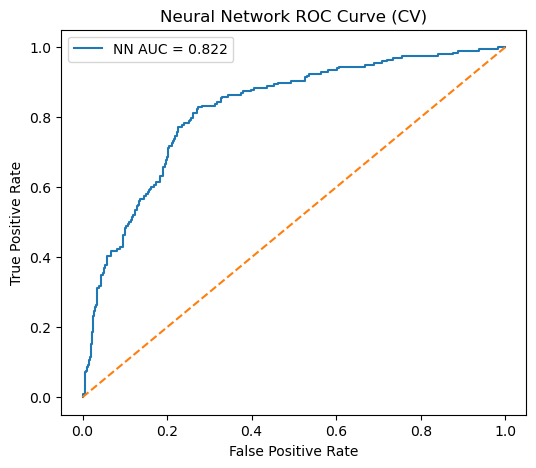

In [165]:
from sklearn.metrics import roc_curve, auc

fpr_nn, tpr_nn, _ = roc_curve(nn_y_true_cv, nn_y_prob_cv)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(6,5))
plt.plot(fpr_nn, tpr_nn, label=f"NN AUC = {roc_auc_nn:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve (CV)")
plt.legend()
plt.show()

In [166]:
final_nn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64,32),
        max_iter=500,
        random_state=42
    ))
])

final_nn.fit(X_train, y_train)

nn_test_pred = final_nn.predict(X_test)
nn_test_prob = final_nn.predict_proba(X_test)[:, 1]

In [167]:
print("Neural Network Test Results")
print("Accuracy:", accuracy_score(y_test, nn_test_pred))
print("Precision:", precision_score(y_test, nn_test_pred))
print("Recall:", recall_score(y_test, nn_test_pred))
print("F1:", f1_score(y_test, nn_test_pred))
print("AUC:", roc_auc_score(y_test, nn_test_prob))

Neural Network Test Results
Accuracy: 0.77
Precision: 0.5405405405405406
Recall: 0.40816326530612246
F1: 0.46511627906976744
AUC: 0.7695634545208812


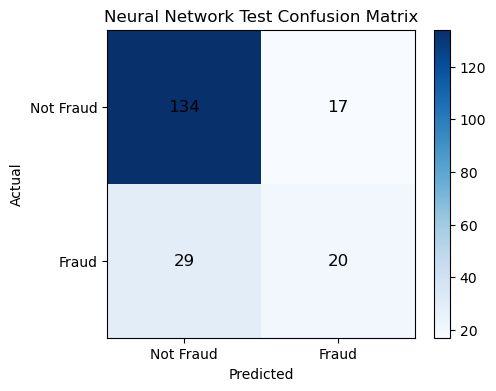

In [168]:
cm_nn_test = confusion_matrix(y_test, nn_test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm_nn_test, cmap="Blues")
plt.title("Neural Network Test Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nn_test[i, j],
                 ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

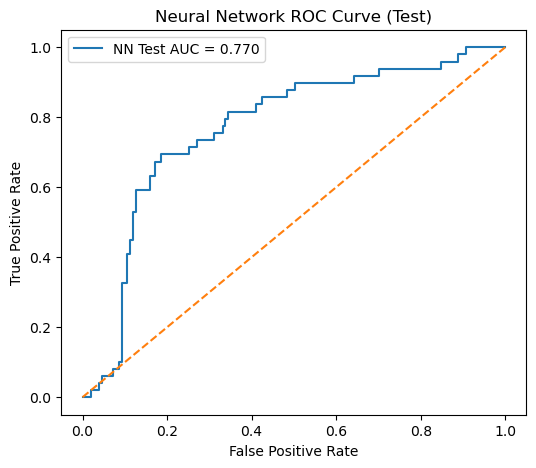

In [169]:
fpr_nn_test, tpr_nn_test, _ = roc_curve(y_test, nn_test_prob)
roc_auc_nn_test = auc(fpr_nn_test, tpr_nn_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_nn_test, tpr_nn_test, label=f"NN Test AUC = {roc_auc_nn_test:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Neural Network ROC Curve (Test)")
plt.legend()
plt.show()

交叉驗證結果顯示模型具有良好的分類能力（AUC = 0.822），而在測試資料上 AUC 為 0.770，略低於訓練過程，顯示模型存在輕微過擬合現象。然而整體差距不大，顯示模型仍具備一定的泛化能力。

## 羅吉斯

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_y_true_cv = []
lr_y_pred_cv = []
lr_y_prob_cv = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"===== Fold {fold} =====")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    lr_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ])

    lr_pipe.fit(X_tr, y_tr)

    y_pred = lr_pipe.predict(X_val)
    y_prob = lr_pipe.predict_proba(X_val)[:, 1]

    lr_y_true_cv.extend(y_val)
    lr_y_pred_cv.extend(y_pred)
    lr_y_prob_cv.extend(y_prob)

===== Fold 1 =====
===== Fold 2 =====
===== Fold 3 =====
===== Fold 4 =====
===== Fold 5 =====


In [171]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Logistic Regression CV Results")
print("Accuracy:", accuracy_score(lr_y_true_cv, lr_y_pred_cv))
print("Precision:", precision_score(lr_y_true_cv, lr_y_pred_cv))
print("Recall:", recall_score(lr_y_true_cv, lr_y_pred_cv))
print("F1:", f1_score(lr_y_true_cv, lr_y_pred_cv))
print("AUC:", roc_auc_score(lr_y_true_cv, lr_y_prob_cv))

Logistic Regression CV Results
Accuracy: 0.82
Precision: 0.608
Recall: 0.7676767676767676
F1: 0.6785714285714286
AUC: 0.8614466928420417


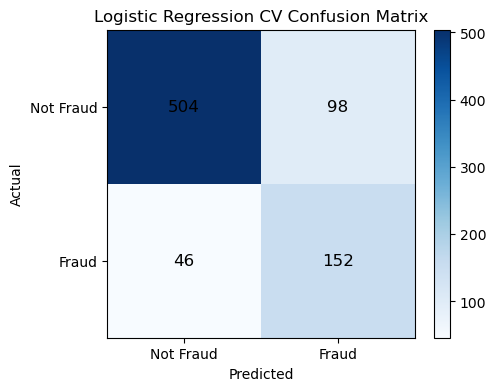

In [172]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_lr_cv = confusion_matrix(lr_y_true_cv, lr_y_pred_cv)

plt.figure(figsize=(5,4))
plt.imshow(cm_lr_cv, cmap="Blues")
plt.title("Logistic Regression CV Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr_cv[i, j],
                 ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

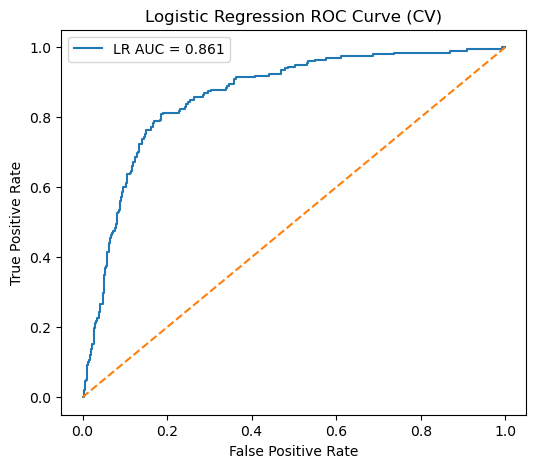

In [173]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(lr_y_true_cv, lr_y_prob_cv)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC = {roc_auc_lr:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve (CV)")
plt.legend()
plt.show()

In [174]:
final_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

final_lr.fit(X_train, y_train)

lr_test_pred = final_lr.predict(X_test)
lr_test_prob = final_lr.predict_proba(X_test)[:, 1]

In [175]:
print("Logistic Regression Test Results")
print("Accuracy:", accuracy_score(y_test, lr_test_pred))
print("Precision:", precision_score(y_test, lr_test_pred))
print("Recall:", recall_score(y_test, lr_test_pred))
print("F1:", f1_score(y_test, lr_test_pred))
print("AUC:", roc_auc_score(y_test, lr_test_prob))

Logistic Regression Test Results
Accuracy: 0.81
Precision: 0.5932203389830508
Recall: 0.7142857142857143
F1: 0.6481481481481481
AUC: 0.8174077578051088


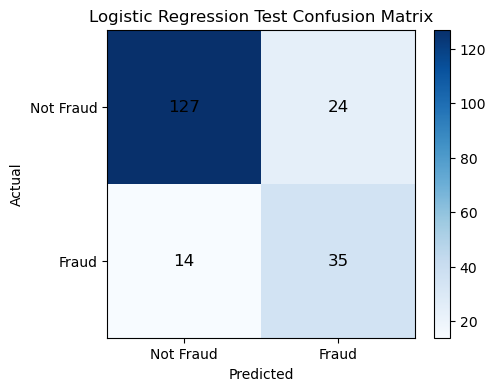

In [176]:
cm_lr_test = confusion_matrix(y_test, lr_test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm_lr_test, cmap="Blues")
plt.title("Logistic Regression Test Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr_test[i, j],
                 ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

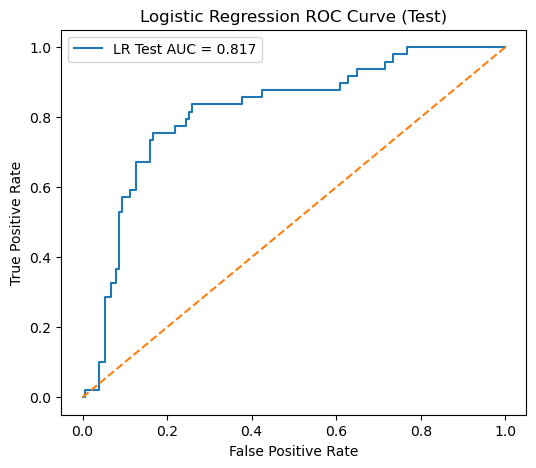

In [177]:
fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test, lr_test_prob)
roc_auc_lr_test = auc(fpr_lr_test, tpr_lr_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr_test, tpr_lr_test, label=f"LR Test AUC = {roc_auc_lr_test:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve (Test)")
plt.legend()
plt.show()

Logistic Regression 在交叉驗證中達到 AUC 0.861，在測試資料上為 0.817，顯示模型具有良好的預測能力。兩者差距約為 0.044，屬於正常範圍，表示模型具有穩定的泛化能力。

## 比較

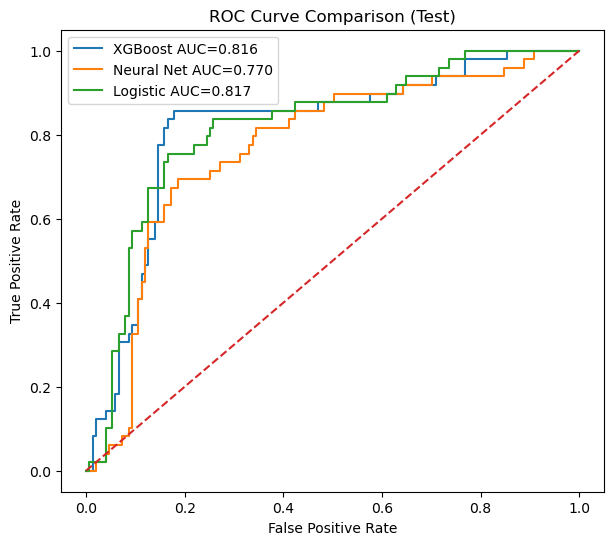

In [178]:
plt.figure(figsize=(7,6))

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_prob)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC={roc_auc_score(y_test, xgb_test_prob):.3f}")

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_test_prob)
plt.plot(fpr_nn, tpr_nn, label=f"Neural Net AUC={roc_auc_score(y_test, nn_test_prob):.3f}")

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_prob)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic AUC={roc_auc_score(y_test, lr_test_prob):.3f}")

# baseline
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Test)")
plt.legend()
plt.show()

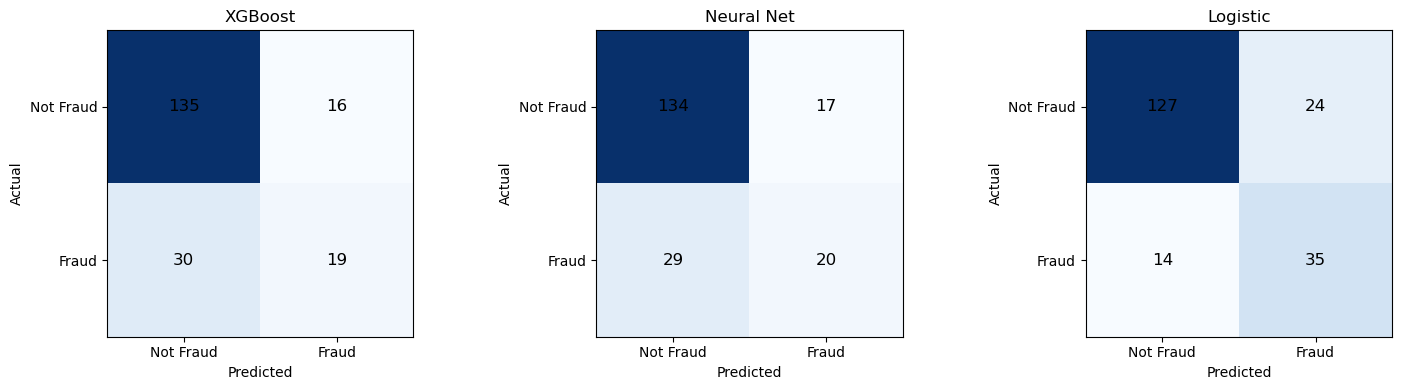

In [179]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

cms = [
    (confusion_matrix(y_test, xgb_test_pred), "XGBoost"),
    (confusion_matrix(y_test, nn_test_pred), "Neural Net"),
    (confusion_matrix(y_test, lr_test_pred), "Logistic")
]

for ax, (cm, title) in zip(axes, cms):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Not Fraud", "Fraud"])
    ax.set_yticklabels(["Not Fraud", "Fraud"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j],
                    ha="center", va="center", fontsize=12)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

本研究比較 Logistic Regression、Neural Network 與 XGBoost 三種模型於詐欺偵測之表現。結果顯示，Logistic Regression 在測試資料上具有最佳表現（AUC = 0.817），且與交叉驗證結果差距最小，顯示其具有良好的穩定性與泛化能力。XGBoost 表現與 Logistic 相近（AUC = 0.816），顯示其在捕捉非線性關係方面具備優勢。相較之下，Neural Network 表現較差，可能因資料量不足而未能發揮其潛力。

## Threshold_XGboost

In [188]:
y_true = np.array(y_test)
y_prob = np.array(xgb_test_prob) 

In [189]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.01)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([t, precision, recall, f1])

Best Threshold => 最大F1

In [190]:
results = np.array(results)

best_idx = np.argmax(results[:, 3])   
best_t = results[best_idx, 0]
best_precision = results[best_idx, 1]
best_recall = results[best_idx, 2]
best_f1 = results[best_idx, 3]

print("=== Best Threshold by F1 ===")
print(f"Best threshold: {best_t:.2f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1-score: {best_f1:.4f}")

=== Best Threshold by F1 ===
Best threshold: 0.12
Precision: 0.6087
Recall: 0.8571
F1-score: 0.7119


In [191]:
y_pred_best = (y_prob >= best_t).astype(int)

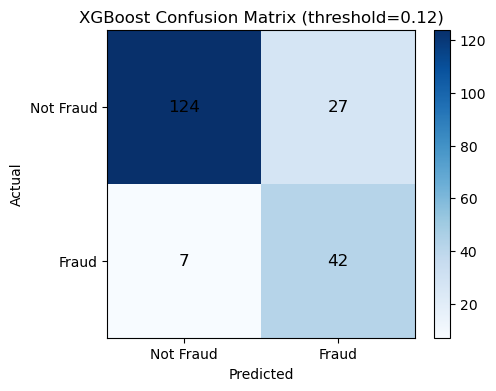

In [193]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_best, cmap="Blues")
plt.title(f"XGBoost Confusion Matrix (threshold={best_t:.2f})")
plt.colorbar()

plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.yticks([0, 1], ["Not Fraud", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_best[i, j], ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Recall = TP / (TP + FN)
       = 42 / (42 + 7)
       ≈ 0.857
85.7% 的詐欺被抓到，
Precision = TP / (TP + FP)
          = 42 / (42 + 28)
          ≈ 0.60
只有 60% 判為詐欺是真的，
在 threshold = 0.1 下，模型的 recall 提升至 85.7%，顯示大部分詐欺案件能被成功偵測。然而 precision 降至約 60%，表示誤判率增加。此結果顯示在降低 threshold 的情況下，模型傾向提高詐欺偵測能力，但需付出較高誤判成本。

## Try

In [194]:
sample = {
    'age': 35,
    'policy_annual_premium': 1200,
    'policy_deductable': 1000,
    'number_of_vehicles_involved': 2,
    'bodily_injuries': 1,
    'witnesses': 2,
    'vehicle_age': 5,
    'umbrella_limit_yes': 0,
    'capital_gains_yes': 5000,
    'capital_loss_yes': 0,
    'policy_state': 'OH',
    'insured_sex': 'MALE',
    'insured_education_level': 'Bachelor',
    'insured_occupation': 'engineer',
    'insured_hobbies': 'reading',
    'insured_relationship': 'self',
    'incident_type': 'Single Vehicle Collision',
    'collision_type': 'Rear Collision',
    'incident_severity': 'Minor Damage',
    'authorities_contacted': 'Police',
    'incident_state': 'OH',
    'incident_city': 'Columbus',
    'property_damage': 'NO',
    'police_report_available': 'YES',
    'auto_make': 'Honda',
    'policy_bind_daytype': 'weekday',
    'incident_day_type': 'weekday',
    'incident_time_period': 'afternoon',
    'injury_claim_level': 'low',
    'property_claim_level': 'low',
    'vehicle_claim_level': 'low',
    'policy_bind_month': 6,
    'csl_accident': 500
}

In [195]:
sample_df = pd.DataFrame([sample])

In [196]:
prob = final_xgb.predict_proba(sample_df)[0][1]
print("Fraud probability:", prob)

Fraud probability: 0.093103416


In [197]:
threshold = 0.1

prediction = 1 if prob >= threshold else 0

print("Prediction:", "Fraud" if prediction == 1 else "Not Fraud")

Prediction: Not Fraud
